In [1]:
import cv2
import dlib
import matplotlib.pyplot as plt
import os
import shutil
# from moviepy.editor import VideoFileClip
import numpy as np
import matplotlib.patches as patches
from tabulate import tabulate
import pandas as pd
from typing import Iterable, Optional
from multiprocessing import Pool, cpu_count
np.set_printoptions(threshold=np.inf)

In [30]:
# Load detector & landmark predictor
detector = dlib.get_frontal_face_detector()
face_predictor_path = "models/shape_predictor_68_face_landmarks.dat"
predictor = dlib.shape_predictor(face_predictor_path)

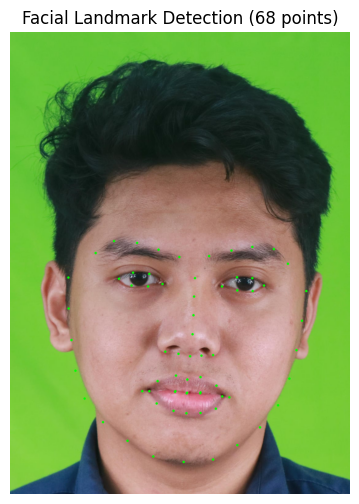

In [ ]:
# Read image
image_path = "images/gambar4.jpg"
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Detect face
faces = detector(gray)

for face in faces:
    landmarks = predictor(gray, face)

    for n in range(68):
        x = landmarks.part(n).x
        y = landmarks.part(n).y
        cv2.circle(image, (x, y), 4, (0, 255, 0), -1)

# OpenCV -> RGB (penting untuk matplotlib)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Tampilkan sebagai gambar
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Facial Landmark Detection (68 points)")
plt.show()


Gambar berhasil dimuat. Ukuran: (1508, 1109, 3)
Jumlah wajah yang terdeteksi: 1
Memproses wajah 1
Koordinat wajah: (154, 582) - (924, 1352)
Menampilkan hasil...
Gambar diresize ke: 588x800


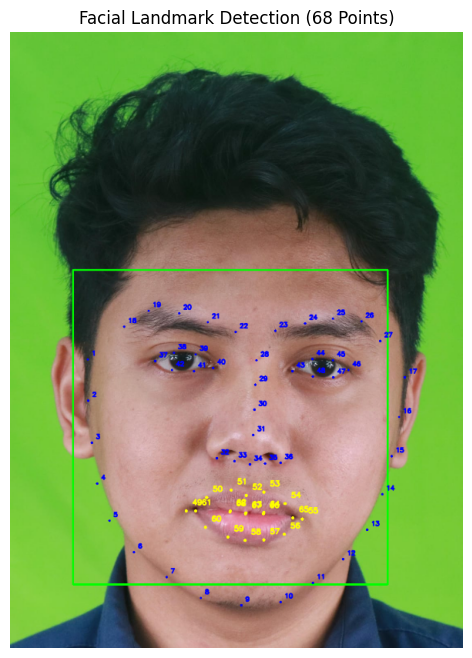

In [ ]:
# Cek apakah file gambar ada
if not os.path.exists(image_path):
    print(f"ERROR: File gambar tidak ditemukan: {image_path}")
    exit()

image = cv2.imread(image_path)
if image is None:
    print(f"ERROR: Tidak bisa membaca gambar: {image_path}")
    exit()

print(f"Gambar berhasil dimuat. Ukuran: {image.shape}")

# Buat copy dari gambar asli
result_image = image.copy()
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Deteksi wajah
faces = detector(gray)
print(f"Jumlah wajah yang terdeteksi: {len(faces)}")

if len(faces) == 0:
    print("PERINGATAN: Tidak ada wajah yang terdeteksi!")
    print("Mencoba dengan parameter yang berbeda...")

    # Coba deteksi dengan upsampling
    faces = detector(gray, 1)
    print(f"Jumlah wajah setelah upsampling: {len(faces)}")

for i, face in enumerate(faces):
    print(f"Memproses wajah {i+1}")
    print(f"Koordinat wajah: ({face.left()}, {face.top()}) - ({face.right()}, {face.bottom()})")

    # Gambar kotak di sekitar wajah
    cv2.rectangle(result_image, (face.left(), face.top()),
                  (face.right(), face.bottom()), (0, 255, 0), 3)

    # Landmark di wajah
    landmarks = predictor(gray, face)

    for n in range(0, 68):
        x = landmarks.part(n).x
        y = landmarks.part(n).y

        # Khusus mulut: warna kuning
        if 48 <= n <= 67:
            color = (0, 255, 255)  # Kuning untuk mulut
            offset_x, offset_y = 15, -15
            circle_radius = 4
            font_scale = 0.6
        else:
            color = (255, 0, 0)  # Biru untuk yang lain
            offset_x, offset_y = 10, -10
            circle_radius = 3
            font_scale = 0.5

        # Titik landmark
        cv2.circle(result_image, (x, y), circle_radius, color, -1)

        # Angka urutan
        cv2.putText(result_image, str(n + 1), (x + offset_x, y + offset_y),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, color, 2, cv2.LINE_AA)

# Jika tidak ada wajah terdeteksi, tampilkan gambar asli
if len(faces) == 0:
    print("Menampilkan gambar asli karena tidak ada wajah terdeteksi")
    result_image = image

print("Menampilkan hasil...")

# Resize jika gambar terlalu besar
height, width = result_image.shape[:2]
if width > 1200 or height > 800:
    scale = min(1200/width, 800/height)
    new_width = int(width * scale)
    new_height = int(height * scale)
    result_image = cv2.resize(result_image, (new_width, new_height))
    print(f"Gambar diresize ke: {new_width}x{new_height}")

result_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(result_rgb)
plt.axis("off")
plt.title("Facial Landmark Detection (68 Points)")
plt.show()

## Extract Frame

In [29]:
import os
import cv2
import shutil
from typing import Iterable, Optional
from multiprocessing import Pool, cpu_count


def _process_video(args):
    video_path, output_dir, video_ext = args
    root, fname = os.path.split(video_path)

    ext = os.path.splitext(fname)[1].lower()
    if video_ext is not None and ext not in video_ext:
        return

    parts = root.split(os.sep)

    # condition
    if "before" in parts:
        condition = "before"
        idx = parts.index("before")
    elif "after" in parts:
        condition = "after"
        idx = parts.index("after")
    else:
        return

    # label & subject
    label = parts[idx + 1] if len(parts) > idx + 1 else "unknown_label"
    subject = parts[idx + 2] if len(parts) > idx + 2 else "unknown_subject"
    question = next((p for p in parts if p.lower().startswith("q")), "unknown")

    name = fname.lower()
    if "_main" in name:
        device = "device_main"
    elif "_sec" in name:
        device = "device_sec"
    else:
        device = "device_unknown"

    out_dir = os.path.join(
        output_dir, condition, label, subject, question, device
    )
    os.makedirs(out_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return

    frame_idx = 1
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imwrite(os.path.join(out_dir, f"img{frame_idx:04d}.jpg"), frame)
        frame_idx += 1

    cap.release()
    print(f"✅ {condition}/{label}/{subject}/{question}/{device} -> {frame_idx-1} frame")


def extract_frames_parallel(
    input_dir: str,
    output_dir: str,
    video_ext: Optional[Iterable[str]] = None,
    clean_output: bool = True,
    n_proc: int = None,
):
    if clean_output and os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir, exist_ok=True)

    if video_ext is not None:
        video_ext = {e.lower() for e in video_ext}

    video_files = []
    for root, _, files in os.walk(input_dir):
        for f in files:
            video_files.append(os.path.join(root, f))

    n_proc = n_proc or max(1, cpu_count() - 2)

    with Pool(n_proc) as pool:
        pool.map(
            _process_video,
            [(vf, output_dir, video_ext) for vf in video_files]
        )


In [58]:
extract_frames_parallel(
    input_dir="./testing/",
    output_dir="./testing/new_images",
    video_ext=[".avi"],
    n_proc=6
)

✅ before/anxiety/nahdia_putri_safira_1765171578941/q1/device_sec -> 823 frame
✅ before/anxiety/ananda_satria_putra_nugraha_1765167942203/q4/device_sec -> 790 frame
✅ before/anxiety/achmad_anfasa_rabbany_1765271116146/q4/device_sec -> 200 frame
✅ before/anxiety/tomi_martino_affandi_1765265168562/q3/device_sec -> 569 frame
✅ before/tidak/nabeel_nizam_1765258452319/q1/device_sec -> 583 frame
✅ before/tidak/dewita_anggraini_1765269136205/q4/device_sec -> 377 frame
✅ before/tidak/rahmad_dwi_ferdyan_1765266777462/q2/device_sec -> 353 frame
✅ before/tidak/tora_digda_kristiawan_1765184694854/q5/device_sec -> 1072 frame


## Extract ROI

In [37]:
# ======================================================
# KONFIGURASI
# ======================================================
PREDICTOR_PATH = "models/shape_predictor_68_face_landmarks.dat"

REGIONS = {
    "mulut": list(range(48, 68)),
    "mata_kiri": list(range(17, 22)) + list(range(36, 42)),
    "mata_kanan": list(range(22, 27)) + list(range(42, 48)),
}

TARGET_SIZE = {
    "mulut": (70, 35),
    "mata_kiri": (48, 32),
    "mata_kanan": (48, 32),
}

PADDING_X = 6
PADDING_Y = 8

# ======================================================
# LOAD MODEL
# ======================================================
if not os.path.exists(PREDICTOR_PATH):
    raise FileNotFoundError(f"Predictor tidak ditemukan: {PREDICTOR_PATH}")

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(PREDICTOR_PATH)

# ======================================================
# UTIL
# ======================================================
def extract_region(image, landmarks, indices):
    pts = [(landmarks.part(i).x, landmarks.part(i).y) for i in indices]
    xs, ys = zip(*pts)

    left = max(0, min(xs) - PADDING_X)
    top = max(0, min(ys) - PADDING_Y)
    right = min(image.shape[1], max(xs) + PADDING_X)
    bottom = min(image.shape[0], max(ys) + PADDING_Y)

    return image[top:bottom, left:right]


In [36]:
# ======================================================
# ROI EXTRACTION (PARALLEL PER SEQUENCE)
# ======================================================

def _process_roi_sequence(args):
    seq_dir, output_dir = args
    parts = seq_dir.split(os.sep)

    if "before" in parts:
        condition, idx = "before", parts.index("before")
    elif "after" in parts:
        condition, idx = "after", parts.index("after")
    else:
        return

    label = parts[idx + 1] if len(parts) > idx + 1 else "unknown_label"
    subject = parts[idx + 2] if len(parts) > idx + 2 else "unknown_subject"
    question = next((p for p in parts if p.lower().startswith("q")), "unknown")
    device = next((p for p in parts if p.startswith("device_")), "device_unknown")

    for fname in sorted(os.listdir(seq_dir)):
        if not fname.lower().endswith(".jpg"):
            continue

        img_path = os.path.join(seq_dir, fname)
        image = cv2.imread(img_path)
        if image is None:
            continue

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        faces = detector(gray)
        if len(faces) == 0:
            continue

        landmarks = predictor(gray, faces[0])

        for region_name, lm_indices in REGIONS.items():
            roi = extract_region(image, landmarks, lm_indices)
            if roi.size == 0:
                continue

            roi = cv2.resize(roi, TARGET_SIZE[region_name])

            out_dir = os.path.join(
                output_dir,
                condition,
                label,
                subject,
                question,
                device,
                region_name,
            )
            os.makedirs(out_dir, exist_ok=True)

            cv2.imwrite(os.path.join(out_dir, fname), roi)

    print(f"✅ ROI {condition}/{label}/{subject}/{question}/{device}")


# ======================================================
# PARALLEL ROI PIPELINE
# ======================================================

def extract_roi_images_parallel(input_dir: str, output_dir: str, n_proc: int = None):
    seq_dirs = []

    for root, _, files in os.walk(input_dir):
        if any(f.lower().endswith(".jpg") for f in files):
            seq_dirs.append(root)

    n_proc = n_proc or max(1, cpu_count() - 2)

    with Pool(n_proc) as pool:
        pool.map(
            _process_roi_sequence,
            [(d, output_dir) for d in seq_dirs]
        )


In [59]:
extract_roi_images_parallel(
    input_dir="testing/new_images",
    output_dir="testing/roi_images",
    n_proc=6
)


✅ ROI before/anxiety/achmad_anfasa_rabbany_1765271116146/q4/device_sec
✅ ROI before/tidak/dewita_anggraini_1765269136205/q4/device_sec
✅ ROI before/tidak/rahmad_dwi_ferdyan_1765266777462/q2/device_sec
✅ ROI before/anxiety/tomi_martino_affandi_1765265168562/q3/device_sec
✅ ROI before/tidak/nabeel_nizam_1765258452319/q1/device_sec
✅ ROI before/anxiety/ananda_satria_putra_nugraha_1765167942203/q4/device_sec
✅ ROI before/anxiety/nahdia_putri_safira_1765171578941/q1/device_sec
✅ ROI before/tidak/tora_digda_kristiawan_1765184694854/q5/device_sec


code untuk import nilai ke csv dan excel

## Extract To POC-ABS & 4mqv

In [39]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

In [40]:
from features_extraction.poc import POC
from features_extraction.vektor import Vektor
from features_extraction.quadran import Quadran
import re

# ======================================================
# CONFIGURATION
# ======================================================
ROI_BASE = "testing/roi_images"
OUTPUT_BASE = "testing/features"
BLOCK_SIZE = 7

COMPONENTS = ["mata_kiri", "mata_kanan", "mulut"]
QUADRANS = ["Q1", "Q2", "Q3", "Q4"]


def natural_sort_key(s):
    return [int(t) if t.isdigit() else t.lower()
            for t in re.split(r'(\d+)', s)]

In [41]:
def process_subject(args):
    condition, class_label, subject = args

    base_path = os.path.join(ROI_BASE, condition, class_label, subject)
    if not os.path.isdir(base_path):
        return

    rows_flat = []
    rows_quad = []

    for question in sorted(os.listdir(base_path)):
        q_path = os.path.join(base_path, question)
        if not os.path.isdir(q_path):
            continue

        for device in sorted(os.listdir(q_path)):
            device_path = os.path.join(q_path, device)
            if not os.path.isdir(device_path):
                continue

            # ==========================================
            # PROCESS PER FRAME (1 FRAME = 1 ROW)
            # ==========================================
            frames_per_component = {}

            for comp in COMPONENTS:
                comp_path = os.path.join(device_path, comp)
                if not os.path.isdir(comp_path):
                    break

                frames = sorted(
                    [f for f in os.listdir(comp_path) if f.endswith(".jpg")],
                    key=natural_sort_key
                )
                if len(frames) < 2:
                    break

                frames_per_component[comp] = frames

            if len(frames_per_component) != len(COMPONENTS):
                continue

            # baseline per component
            baseline = {}
            for comp, frames in frames_per_component.items():
                img = cv2.imread(os.path.join(device_path, comp, frames[0]), 0)
                if img is None:
                    break
                baseline[comp] = img

            # ==========================================
            # LOOP FRAME INDEX (SEQUENCE SAFE)
            # ==========================================
            for idx in range(1, len(next(iter(frames_per_component.values())))):
                frame_no = idx + 1

                flat_row = {
                    "condition": condition,
                    "subject": subject,
                    "question": question,
                    "device": device,
                    "frame": frame_no,
                }

                quad_row = flat_row.copy()

                for comp in COMPONENTS:
                    img_path = os.path.join(
                        device_path, comp, frames_per_component[comp][idx]
                    )
                    img = cv2.imread(img_path, 0)
                    if img is None:
                        break

                    poc = POC(baseline[comp], img, BLOCK_SIZE)
                    vec = Vektor(poc.getPOC(), BLOCK_SIZE)
                    quad = Quadran(vec.getVektor()).getQuadran()

                    # ---------- FLATTEN ----------
                    for b_id, qd in enumerate(quad, start=1):
                        flat_row[f"{comp}_x{b_id}"] = qd[1]
                        flat_row[f"{comp}_y{b_id}"] = qd[2]
                        flat_row[f"{comp}_t{b_id}"] = qd[3]
                        flat_row[f"{comp}_m{b_id}"] = qd[4]

                    # ---------- QUADRANT SUM (SIGNED) ----------
                    for q in QUADRANS:
                        q_blocks = [b for b in quad if b[5] == q]
                        quad_row[f"{comp}_{q}_x"] = sum(b[1] for b in q_blocks)
                        quad_row[f"{comp}_{q}_y"] = sum(b[2] for b in q_blocks)
                        quad_row[f"{comp}_{q}_t"] = sum(b[3] for b in q_blocks)
                        quad_row[f"{comp}_{q}_m"] = sum(b[4] for b in q_blocks)

                # label klasifikasi
                flat_row["label"] = class_label
                quad_row["label"] = class_label

                rows_flat.append(flat_row)
                rows_quad.append(quad_row)

    # ==========================================
    # SAVE OUTPUT
    # ==========================================
    out_dir = os.path.join(OUTPUT_BASE, condition, class_label, subject)
    os.makedirs(out_dir, exist_ok=True)

    pd.DataFrame(rows_flat).to_excel(
        os.path.join(out_dir, "poc_abs_flatten.xlsx"), index=False
    )
    pd.DataFrame(rows_quad).to_excel(
        os.path.join(out_dir, "poc_abs_quadran_sum.xlsx"), index=False
    )

    print(f"✅ DONE: {condition}/{class_label}/{subject}")


In [42]:
def run_parallel(
    roi_base: str,
    conditions=("before", "after"),
    n_proc: int | None = None,
):
    tasks = []

    for condition in conditions:
        cond_path = os.path.join(roi_base, condition)
        if not os.path.isdir(cond_path):
            continue

        for label in os.listdir(cond_path):
            label_path = os.path.join(cond_path, label)
            if not os.path.isdir(label_path):
                continue

            for subject in os.listdir(label_path):
                tasks.append((condition, label, subject))

    n_proc = n_proc or max(1, cpu_count() - 2)

    with Pool(n_proc) as pool:
        pool.map(process_subject, tasks)


In [60]:
run_parallel(ROI_BASE, n_proc=8)

✅ DONE: before/anxiety/achmad_anfasa_rabbany_1765271116146
✅ DONE: before/tidak/rahmad_dwi_ferdyan_1765266777462
✅ DONE: before/tidak/dewita_anggraini_1765269136205
✅ DONE: before/tidak/nabeel_nizam_1765258452319
✅ DONE: before/anxiety/tomi_martino_affandi_1765265168562
✅ DONE: before/anxiety/nahdia_putri_safira_1765171578941
✅ DONE: before/anxiety/ananda_satria_putra_nugraha_1765167942203
✅ DONE: before/tidak/tora_digda_kristiawan_1765184694854


## Sanity Check Validitas data

In [44]:
def _sanity_check_one(args):
    flat_path, quad_path = args

    df_flat = pd.read_excel(flat_path)
    df_quad = pd.read_excel(quad_path)

    # ---------- basic ----------
    if df_flat.isna().sum().sum() != 0:
        return flat_path, "NaN in flatten"
    if df_quad.isna().sum().sum() != 0:
        return quad_path, "NaN in quadran"

    if np.isinf(df_flat.select_dtypes(include="number")).sum().sum() != 0:
        return flat_path, "Inf in flatten"
    if np.isinf(df_quad.select_dtypes(include="number")).sum().sum() != 0:
        return quad_path, "Inf in quadran"

    dup = df_flat.duplicated(
        ["condition", "label", "subject", "question", "device", "frame"]
    ).sum()
    if dup != 0:
        return flat_path, f"Duplicate rows: {dup}"

    # ---------- quadran sign ----------
    def sign_ok(q, x, y):
        return (
            (q=="Q1" and x>=0 and y>=0) or
            (q=="Q2" and x<=0 and y>=0) or
            (q=="Q3" and x<=0 and y<=0) or
            (q=="Q4" and x>=0 and y<=0) or
            (x==0 and y==0)
        )

    for comp in ["mata_kiri", "mata_kanan", "mulut"]:
        for q in ["Q1","Q2","Q3","Q4"]:
            xcol, ycol = f"{comp}_{q}_x", f"{comp}_{q}_y"
            bad = ~df_quad.apply(
                lambda r: sign_ok(q, r[xcol], r[ycol]),
                axis=1
            )
            if bad.any():
                return quad_path, f"Invalid sign {comp} {q}"

    return flat_path, "OK"

def sanity_check_all(feature_root: str):
    tasks = []

    for condition in os.listdir(feature_root):
        cond_path = os.path.join(feature_root, condition)
        if not os.path.isdir(cond_path):
            continue

        for label in os.listdir(cond_path):
            label_path = os.path.join(cond_path, label)
            if not os.path.isdir(label_path):
                continue

            for subject in os.listdir(label_path):
                subj_path = os.path.join(label_path, subject)

                flat = os.path.join(subj_path, "poc_abs_flatten.xlsx")
                quad = os.path.join(subj_path, "poc_abs_quadran_sum.xlsx")

                if os.path.exists(flat) and os.path.exists(quad):
                    tasks.append((flat, quad))

    n_proc = max(1, cpu_count() - 2)

    with Pool(n_proc) as pool:
        results = pool.map(_sanity_check_one, tasks)

    # ---------- report ----------
    errors = [r for r in results if r[1] != "OK"]

    print("\n=== SANITY CHECK SUMMARY ===")
    print(f"Checked files : {len(results)}")
    print(f"Errors       : {len(errors)}")

    for path, msg in errors:
        print("❌", path, "->", msg)

    if len(errors) == 0:
        print("\n✅ ALL DATA VALID")
    else:
        print("\n❌ BUG FOUND — FIX BEFORE NEXT STEP")

    return errors

In [45]:
sanity_check_all("testing/features")


=== SANITY CHECK SUMMARY ===
Checked files : 3
Errors       : 0

✅ ALL DATA VALID


[]

In [10]:
import os
from collections import defaultdict

def check_folder_distribution(feature_root: str):
    dist = defaultdict(lambda: defaultdict(int))
    total_subjects = 0

    for condition in sorted(os.listdir(feature_root)):
        cond_path = os.path.join(feature_root, condition)
        if not os.path.isdir(cond_path):
            continue

        for label in sorted(os.listdir(cond_path)):
            label_path = os.path.join(cond_path, label)
            if not os.path.isdir(label_path):
                continue

            subjects = [
                s for s in os.listdir(label_path)
                if os.path.isdir(os.path.join(label_path, s))
            ]

            dist[condition][label] = len(subjects)
            total_subjects += len(subjects)

    print("\n=== FOLDER DISTRIBUTION (SUBJECT COUNT) ===")
    for condition in dist:
        for label in dist[condition]:
            print(f"{condition}/{label}: {dist[condition][label]} subjects")

    print("------------------------------------------")
    print(f"TOTAL SUBJECT FOLDERS: {total_subjects}")

    return dist


In [11]:
check_folder_distribution("testing/features")


=== FOLDER DISTRIBUTION (SUBJECT COUNT) ===
before/anxiety: 1 subjects
------------------------------------------
TOTAL SUBJECT FOLDERS: 1


defaultdict(<function __main__.check_folder_distribution.<locals>.<lambda>()>,
            {'before': defaultdict(int, {'anxiety': 1})})

## Prepare SVM

In [16]:
def _process_group(args):
    features_base, output_base, condition, label, file_name = args

    label_path = os.path.join(features_base, condition, label)
    if not os.path.isdir(label_path):
        return

    os.makedirs(output_base, exist_ok=True)

    out_path = os.path.join(output_base, f"{condition}_{label}.csv")

    if os.path.exists(out_path):
        os.remove(out_path)

    first_write = True
    total_rows = 0

    for subject in sorted(os.listdir(label_path)):
        subject_path = os.path.join(label_path, subject)
        if not os.path.isdir(subject_path):
            continue

        fpath = os.path.join(subject_path, file_name)
        if not os.path.isfile(fpath):
            continue

        df = pd.read_excel(fpath)

        df["label"] = label
        df["condition"] = condition
        df["subject"] = subject

        df.to_csv(
            out_path,
            index=False,
            header=first_write,
            mode="w" if first_write else "a",
        )

        first_write = False
        total_rows += len(df)
        del df

    print(f"✅ {condition}_{label}.csv DONE | rows={total_rows}")


In [17]:
def generate_grouped_datasets_parallel(
    features_base="dataset/features",
    output_base="dataset/features_grouped",
    file_name="poc_abs_flatten.xlsx",
    n_proc=2,
):
    os.makedirs(output_base, exist_ok=True)

    tasks = []
    for condition in ["before", "after"]:
        for label in ["anxiety", "tidak"]:
            tasks.append(
                (features_base, output_base, condition, label, file_name)
            )

    with Pool(n_proc) as pool:
        pool.map(_process_group, tasks)


In [7]:
# Flatten
generate_grouped_datasets_parallel(
    file_name="poc_abs_flatten.xlsx",
    output_base="dataset/features_grouped/flatten/",
    n_proc=4
)

# Quadran
generate_grouped_datasets_parallel(
    file_name="poc_abs_quadran_sum.xlsx",
    output_base="dataset/features_grouped/quadran/",
    n_proc=4
)

✅ after_anxiety.csv DONE | rows=48648
✅ before_tidak.csv DONE | rows=57678
✅ after_tidak.csv DONE | rows=61127
✅ before_anxiety.csv DONE | rows=92588
✅ after_anxiety.csv DONE | rows=48648
✅ before_tidak.csv DONE | rows=57678
✅ after_tidak.csv DONE | rows=61127
✅ before_anxiety.csv DONE | rows=92588


## SVM Baseline

In [18]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix


In [24]:
def visualize_svm_results(result_dir: str):
    """
    Visualize final SVM results (internal & external)
    from train_svm_group output directory.
    """

    paths = {
        "int_report": os.path.join(result_dir, "classification_report_internal.csv"),
        "ext_report": os.path.join(result_dir, "classification_report_external.csv"),
        "cm_int": os.path.join(result_dir, "confusion_matrix_internal.png"),
        "cm_ext": os.path.join(result_dir, "confusion_matrix_external.png"),
    }

    # ==========================
    # Load reports
    # ==========================
    df_int = pd.read_csv(paths["int_report"], index_col=0)
    df_ext = pd.read_csv(paths["ext_report"], index_col=0)

    classes = [c for c in df_int.index if c not in ["accuracy", "macro avg", "weighted avg"]]

    # ==========================
    # BAR CHART: RECALL
    # ==========================
    def plot_bar(metric, title, df, suffix):
        values = df.loc[classes, metric]

        plt.figure(figsize=(4, 3))
        plt.bar(classes, values)
        plt.ylim(0, 1)
        plt.ylabel(metric.capitalize())
        plt.title(title)
        plt.tight_layout()
        plt.show()

    plot_bar("recall", "Internal Recall per Class", df_int, "internal")
    plot_bar("recall", "External Recall per Class", df_ext, "external")

    # ==========================
    # BAR CHART: SUPPORT
    # ==========================
    plot_bar("support", "Internal Support per Class", df_int, "internal")
    plot_bar("support", "External Support per Class", df_ext, "external")

    # ==========================
    # SHOW CONFUSION MATRIX IMAGES
    # ==========================
    for name, path in [("Internal", paths["cm_int"]), ("External", paths["cm_ext"])]:
        if os.path.exists(path):
            img = plt.imread(path)
            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"{name} Confusion Matrix")
            plt.show()

    # ==========================
    # QUICK METRIC SUMMARY
    # ==========================
    print("\n=== FINAL METRIC SUMMARY ===")
    print("INTERNAL:")
    print(df_int.loc[classes, ["precision", "recall", "f1-score"]])
    print("\nEXTERNAL:")
    print(df_ext.loc[classes, ["precision", "recall", "f1-score"]])


In [19]:
def save_confusion_matrix(cm, class_names, out_path, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


def save_bar_metrics(report_dict, class_names, out_dir, prefix):
    recall = [report_dict[c]["recall"] for c in class_names]
    support = [report_dict[c]["support"] for c in class_names]

    # Recall
    plt.figure(figsize=(4, 3))
    plt.bar(class_names, recall)
    plt.ylim(0, 1)
    plt.title("Recall per Class")
    plt.ylabel("Recall")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_recall.png"))
    plt.close()

    # Support
    plt.figure(figsize=(4, 3))
    plt.bar(class_names, support)
    plt.title("Support per Class")
    plt.ylabel("Samples")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_support.png"))
    plt.close()

In [20]:
def split_subjects_balanced(
    csv_anxiety,
    csv_tidak,
    n_external=2,
    seed=42,
):
    random.seed(seed)

    df_a = pd.read_csv(csv_anxiety)
    df_t = pd.read_csv(csv_tidak)

    subj_a = list(df_a["subject"].unique())
    subj_t = list(df_t["subject"].unique())

    # ===============================
    # 1) SHUFFLE
    # ===============================
    random.shuffle(subj_a)
    random.shuffle(subj_t)

    # ===============================
    # 2) BALANCE TO MIN
    # ===============================
    n_min = min(len(subj_a), len(subj_t))
    subj_a = subj_a[:n_min]
    subj_t = subj_t[:n_min]

    # ===============================
    # 3) EXTERNAL (SUBJECT-LEVEL)
    # ===============================
    ext_a = subj_a[:n_external]
    ext_t = subj_t[:n_external]

    train_a = subj_a[n_external:]
    train_t = subj_t[n_external:]

    return {
        "train": {
            "anxiety": train_a,
            "tidak": train_t,
        },
        "external": {
            "anxiety": ext_a,
            "tidak": ext_t,
        },
        "stats": {
            "balanced_per_class": n_min,
            "train_per_class": len(train_a),
            "external_per_class": n_external,
        }
    }

def build_df_by_subject(csv_path, subjects):
    df = pd.read_csv(csv_path)
    df = pd.read_csv(csv_path)
    return df[df["subject"].isin(subjects)].reset_index(drop=True)

In [21]:
def train_svm_group(
    csv_anxiety,
    csv_tidak,
    out_dir,
    kernel="rbf",
    n_external=2,
):
    os.makedirs(out_dir, exist_ok=True)

    # ==================================================
    # 1) SUBJECT-LEVEL SPLIT
    # ==================================================
    split = split_subjects_balanced(
        csv_anxiety,
        csv_tidak,
        n_external=2,
        seed=42,
    )

    df_train = pd.concat([
        build_df_by_subject(csv_anxiety, split["train"]["anxiety"]),
        build_df_by_subject(csv_tidak, split["train"]["tidak"]),
    ], ignore_index=True)

    df_external = pd.concat([
        build_df_by_subject(csv_anxiety, split["external"]["anxiety"]),
        build_df_by_subject(csv_tidak, split["external"]["tidak"]),
    ], ignore_index=True)

    print("📊 SUBJECT STATS:", split["stats"])

    # ==================================================
    # 2) BUILD X, y (TRAIN)
    # ==================================================
    drop_cols = ["label", "condition", "subject", "question", "device", "frame"]
    X = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns])
    y = df_train["label"]

    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    imputer = SimpleImputer(strategy="mean")
    X = imputer.fit_transform(X)

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # ==================================================
    # 3) INTERNAL SPLIT (80/20)
    # ==================================================
    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y_enc,
        test_size=0.2,
        stratify=y_enc,
        random_state=42
    )

    # ==================================================
    # 4) TRAIN MODEL
    # ==================================================
    model = SVC(kernel=kernel, C=1)
    model.fit(X_tr, y_tr)

    # ==================================================
    # 5) INTERNAL EVALUATION
    # ==================================================
    y_val_pred = model.predict(X_val)

    report_int = classification_report(
        y_val,
        y_val_pred,
        target_names=le.classes_,
        output_dict=True
    )
    cm_int = confusion_matrix(y_val, y_val_pred)

    save_confusion_matrix(
        cm_int,
        le.classes_,
        os.path.join(out_dir, "confusion_matrix_internal.png"),
        title=f"SVM Internal Confusion Matrix ({kernel})"
    )

    save_bar_metrics(
        report_int,
        le.classes_,
        out_dir,
        prefix="internal"
    )

    pd.DataFrame(report_int).transpose().to_csv(
        os.path.join(out_dir, "classification_report_internal.csv")
    )

    # ==================================================
    # 6) EXTERNAL TEST
    # ==================================================
    X_ext = df_external.drop(columns=[c for c in drop_cols if c in df_external.columns])
    y_ext = le.transform(df_external["label"])

    X_ext = imputer.transform(X_ext)
    X_ext = scaler.transform(X_ext)

    y_ext_pred = model.predict(X_ext)

    report_ext = classification_report(
        y_ext,
        y_ext_pred,
        target_names=le.classes_,
        output_dict=True
    )
    cm_ext = confusion_matrix(y_ext, y_ext_pred)

    save_confusion_matrix(
        cm_ext,
        le.classes_,
        os.path.join(out_dir, "confusion_matrix_external.png"),
        title=f"SVM External Confusion Matrix ({kernel})"
    )

    save_bar_metrics(
        report_ext,
        le.classes_,
        out_dir,
        prefix="external"
    )

    pd.DataFrame(report_ext).transpose().to_csv(
        os.path.join(out_dir, "classification_report_external.csv")
    )

    # ==================================================
    # 7) SAVE ARTIFACTS
    # ==================================================
    joblib.dump(model, os.path.join(out_dir, "svm_model.joblib"))
    joblib.dump(scaler, os.path.join(out_dir, "scaler.joblib"))
    joblib.dump(imputer, os.path.join(out_dir, "imputer.joblib"))
    joblib.dump(le, os.path.join(out_dir, "label_encoder.joblib"))

    print("✅ TRAINING + EXTERNAL TEST DONE")
    print(f"📁 Output: {out_dir}")


### SVM Flatten All Data

#### Before

In [7]:
train_svm_group(
    csv_anxiety="dataset/features_grouped/flatten/before_anxiety.csv",
    csv_tidak="dataset/features_grouped/flatten/before_tidak.csv",
    out_dir="models/svm_before/flatten/",
    kernel="rbf"
)


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     anxiety       0.97      0.98      0.97     18518
       tidak       0.97      0.94      0.96     11536

    accuracy                           0.97     30054
   macro avg       0.97      0.96      0.97     30054
weighted avg       0.97      0.97      0.97     30054

Confusion Matrix:
[[18189   329]
 [  659 10877]]
✅ Model saved in: models/svm_before/flatten/


#### After

In [ ]:
train_svm_group(
    csv_anxiety="dataset/features_grouped/flatten/after_anxiety.csv",
    csv_tidak="dataset/features_grouped/flatten/after_tidak.csv",
    out_dir="models/svm_after/flatten/",
    kernel="rbf"
)

In [22]:
import pandas as pd

df_a = pd.read_csv("dataset/features_grouped/flatten/before_anxiety.csv")
df_t = pd.read_csv("dataset/features_grouped/flatten/before_tidak.csv")

print("before anxiety subjects:", df_a["subject"].nunique())
print("before tidak subjects:", df_t["subject"].nunique())


before anxiety subjects: 32
before tidak subjects: 24


### SVM Flatten Data Imbang antar kelas

#### Before

In [23]:
train_svm_group(
    csv_anxiety="dataset/features_grouped/flatten/before_anxiety.csv",
    csv_tidak="dataset/features_grouped/flatten/before_tidak.csv",
    out_dir="models/svm_before/flatten_balanced/",
    kernel="rbf",
    n_external=2
)

📊 SUBJECT STATS: {'balanced_per_class': 24, 'train_per_class': 22, 'external_per_class': 2}
✅ TRAINING + EXTERNAL TEST DONE
📁 Output: models/svm_before/flatten_balanced/


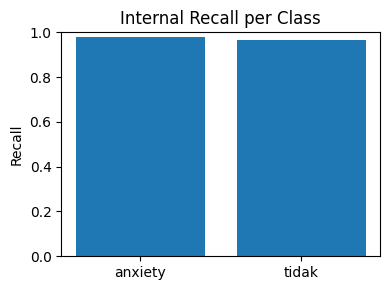

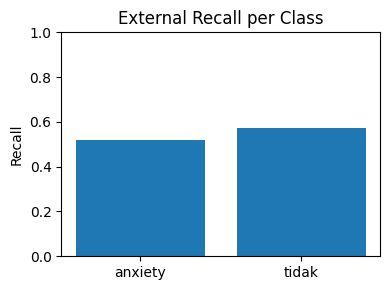

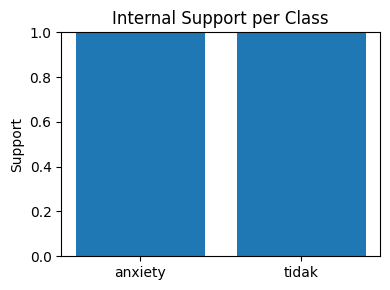

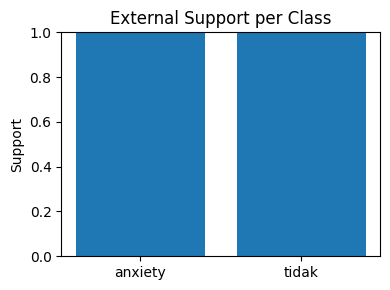

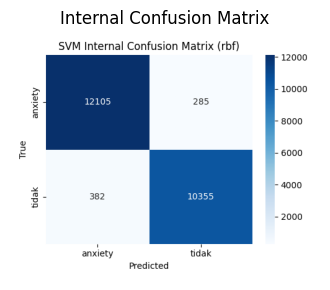

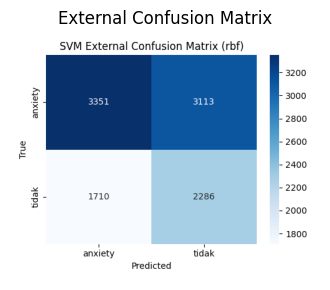


=== FINAL METRIC SUMMARY ===
INTERNAL:
         precision    recall  f1-score
anxiety   0.969408  0.976998  0.973188
tidak     0.973214  0.964422  0.968798

EXTERNAL:
         precision    recall  f1-score
anxiety   0.662122  0.518410  0.581518
tidak     0.423412  0.572072  0.486642


In [25]:
visualize_svm_results(
    "models/svm_before/flatten_balanced/"
)

#### After

In [26]:
train_svm_group(
    csv_anxiety="dataset/features_grouped/flatten/after_anxiety.csv",
    csv_tidak="dataset/features_grouped/flatten/after_tidak.csv",
    out_dir="models/svm_after/flatten_balanced/",
    kernel="rbf",
    n_external=2
)

📊 SUBJECT STATS: {'balanced_per_class': 21, 'train_per_class': 19, 'external_per_class': 2}
✅ TRAINING + EXTERNAL TEST DONE
📁 Output: models/svm_after/flatten_balanced/


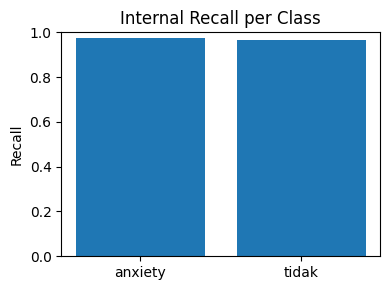

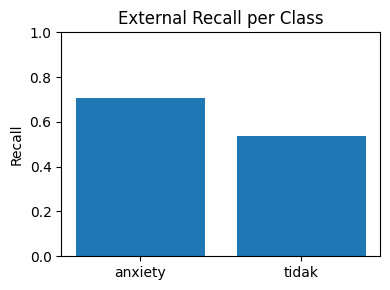

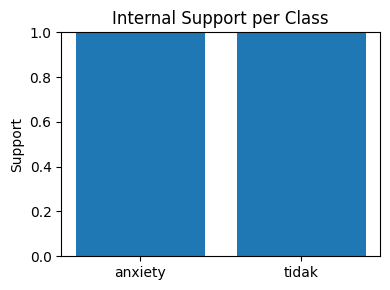

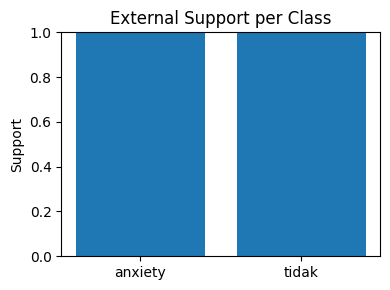

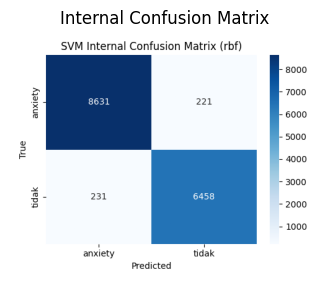

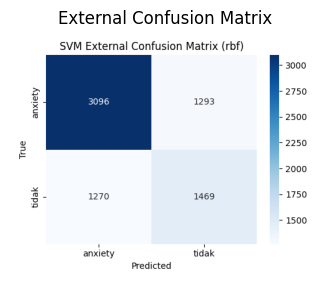


=== FINAL METRIC SUMMARY ===
INTERNAL:
         precision    recall  f1-score
anxiety   0.973934  0.975034  0.974483
tidak     0.966911  0.965466  0.966188

EXTERNAL:
         precision    recall  f1-score
anxiety   0.709116  0.705400  0.707253
tidak     0.531861  0.536327  0.534085


In [27]:
visualize_svm_results(
    "models/svm_after/flatten_balanced/"
)

### SVM Quadran Data Imbang antar kelas

#### Before

In [28]:
train_svm_group(
    csv_anxiety="dataset/features_grouped/quadran/before_anxiety.csv",
    csv_tidak="dataset/features_grouped/quadran/before_tidak.csv",
    out_dir="models/svm_before/quadran_balanced/",
    kernel="rbf",
    n_external=2
)

📊 SUBJECT STATS: {'balanced_per_class': 24, 'train_per_class': 22, 'external_per_class': 2}
✅ TRAINING + EXTERNAL TEST DONE
📁 Output: models/svm_before/quadran_balanced/


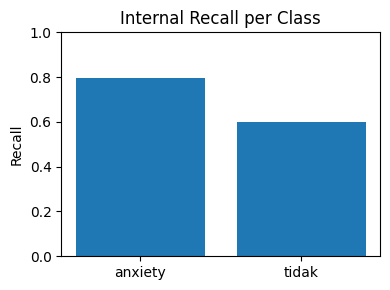

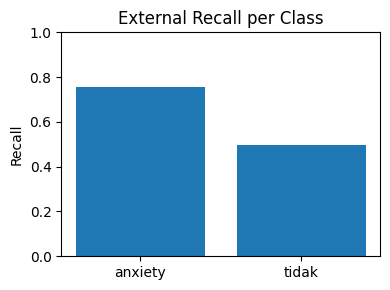

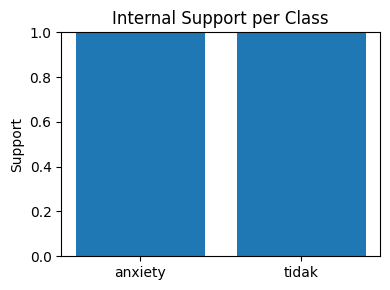

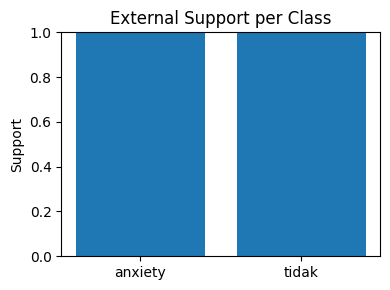

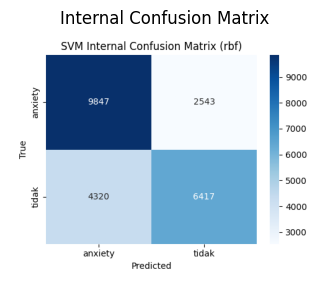

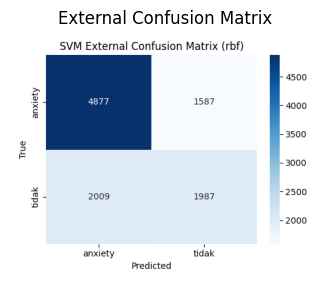


=== FINAL METRIC SUMMARY ===
INTERNAL:
         precision    recall  f1-score
anxiety   0.695066  0.794754  0.741575
tidak     0.716183  0.597653  0.651571

EXTERNAL:
         precision    recall  f1-score
anxiety   0.708249  0.754486  0.730637
tidak     0.555960  0.497247  0.524967


In [29]:
visualize_svm_results(
    "models/svm_before/quadran_balanced/"
)

#### After

In [30]:
train_svm_group(
    csv_anxiety="dataset/features_grouped/quadran/after_anxiety.csv",
    csv_tidak="dataset/features_grouped/quadran/after_tidak.csv",
    out_dir="models/svm_after/quadran_balanced/",
    kernel="rbf",
    n_external=2
)

📊 SUBJECT STATS: {'balanced_per_class': 21, 'train_per_class': 19, 'external_per_class': 2}
✅ TRAINING + EXTERNAL TEST DONE
📁 Output: models/svm_after/quadran_balanced/


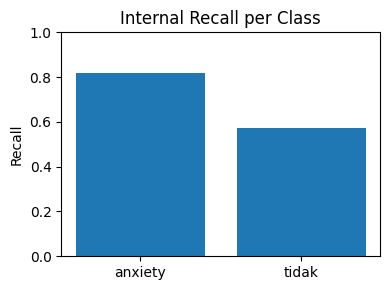

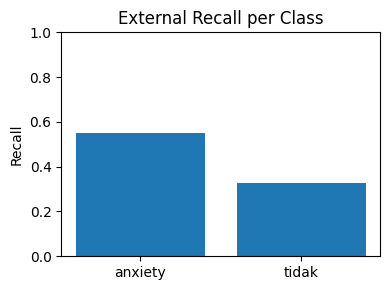

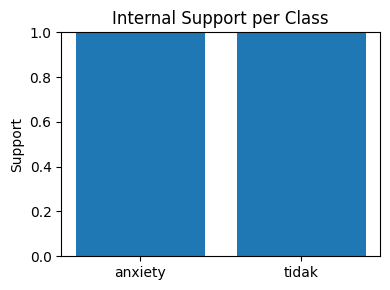

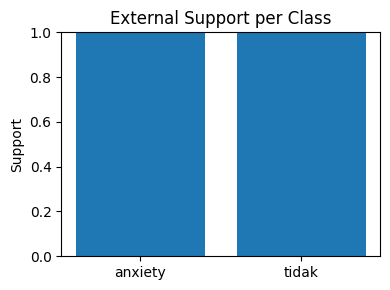

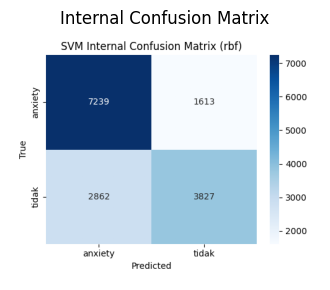

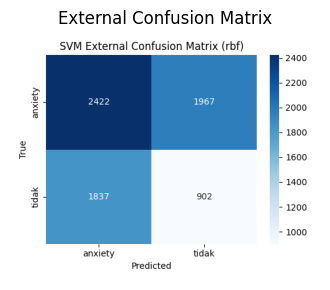


=== FINAL METRIC SUMMARY ===
INTERNAL:
         precision    recall  f1-score
anxiety   0.716662  0.817781   0.76389
tidak     0.703493  0.572133   0.63105

EXTERNAL:
         precision    recall  f1-score
anxiety   0.568678  0.551834  0.560130
tidak     0.314395  0.329317  0.321683


In [31]:
visualize_svm_results(
    "models/svm_after/quadran_balanced/"
)

### SVM Flatten Data Imbang antar kelas Before/After jadi 1

In [39]:
def split_subjects_balanced_merged(
    df,
    label_col="label",
    subject_col="subject",
    n_external=2,
    seed=42,
):
    random.seed(seed)

    subjects_by_label = {
        lbl: sorted(df[df[label_col] == lbl][subject_col].unique())
        for lbl in df[label_col].unique()
    }

    # balance by minimum subject count
    n_min = min(len(v) for v in subjects_by_label.values())

    balanced = {}
    for lbl, subs in subjects_by_label.items():
        balanced[lbl] = random.sample(subs, n_min)

    # external split
    external = {
        lbl: subs[:n_external]
        for lbl, subs in balanced.items()
    }
    train = {
        lbl: subs[n_external:]
        for lbl, subs in balanced.items()
    }

    return {
        "train": train,
        "external": external,
        "stats": {
            "balanced_per_class": n_min,
            "train_per_class": n_min - n_external,
            "external_per_class": n_external,
        }
    }

def build_df_by_subject_merged(df, subjects):
    return df[df["subject"].isin(subjects)].reset_index(drop=True)

In [40]:
def train_svm_group_merged(
    csv_path,
    out_dir,
    kernel="rbf",
    n_external=2,
    seed=42,
):
    os.makedirs(out_dir, exist_ok=True)

    # ==================================================
    # 0) LOAD MERGED DATA
    # ==================================================
    df = pd.read_csv(csv_path)

    # ==================================================
    # 1) SUBJECT-LEVEL BALANCING + SPLIT
    # ==================================================
    split = split_subjects_balanced_merged(
        df,
        n_external=n_external,
        seed=seed,
    )

    df_train = pd.concat([
        build_df_by_subject_merged(df[df["label"] == lbl], subs)
        for lbl, subs in split["train"].items()
    ], ignore_index=True)

    df_external = pd.concat([
        build_df_by_subject_merged(df[df["label"] == lbl], subs)
        for lbl, subs in split["external"].items()
    ], ignore_index=True)

    print("📊 SUBJECT STATS:", split["stats"])

    # ==================================================
    # 2) BUILD X, y (TRAIN)
    # ==================================================
    drop_cols = ["label", "condition", "subject", "question", "device", "frame"]
    X = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns])
    y = df_train["label"]

    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    imputer = SimpleImputer(strategy="mean")
    X = imputer.fit_transform(X)

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # ==================================================
    # 3) INTERNAL SPLIT (80/20)
    # ==================================================
    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y_enc,
        test_size=0.2,
        stratify=y_enc,
        random_state=seed
    )

    # ==================================================
    # 4) TRAIN MODEL
    # ==================================================
    model = SVC(kernel=kernel, C=1)
    model.fit(X_tr, y_tr)

    # ==================================================
    # 5) INTERNAL EVALUATION
    # ==================================================
    y_val_pred = model.predict(X_val)

    report_int = classification_report(
        y_val, y_val_pred,
        target_names=le.classes_,
        output_dict=True
    )
    cm_int = confusion_matrix(y_val, y_val_pred)

    save_confusion_matrix(
        cm_int,
        le.classes_,
        os.path.join(out_dir, "confusion_matrix_internal.png"),
        title=f"SVM Internal Confusion Matrix ({kernel})"
    )

    save_bar_metrics(report_int, le.classes_, out_dir, prefix="internal")

    pd.DataFrame(report_int).transpose().to_csv(
        os.path.join(out_dir, "classification_report_internal.csv")
    )

    # ==================================================
    # 6) EXTERNAL TEST
    # ==================================================
    X_ext = df_external.drop(columns=[c for c in drop_cols if c in df_external.columns])
    y_ext = le.transform(df_external["label"])

    X_ext = imputer.transform(X_ext)
    X_ext = scaler.transform(X_ext)

    y_ext_pred = model.predict(X_ext)

    report_ext = classification_report(
        y_ext, y_ext_pred,
        target_names=le.classes_,
        output_dict=True
    )
    cm_ext = confusion_matrix(y_ext, y_ext_pred)

    save_confusion_matrix(
        cm_ext,
        le.classes_,
        os.path.join(out_dir, "confusion_matrix_external.png"),
        title=f"SVM External Confusion Matrix ({kernel})"
    )

    save_bar_metrics(report_ext, le.classes_, out_dir, prefix="external")

    pd.DataFrame(report_ext).transpose().to_csv(
        os.path.join(out_dir, "classification_report_external.csv")
    )

    # ==================================================
    # 7) SAVE ARTIFACTS
    # ==================================================
    joblib.dump(model, os.path.join(out_dir, "svm_model.joblib"))
    joblib.dump(scaler, os.path.join(out_dir, "scaler.joblib"))
    joblib.dump(imputer, os.path.join(out_dir, "imputer.joblib"))
    joblib.dump(le, os.path.join(out_dir, "label_encoder.joblib"))

    print("✅ TRAINING + EXTERNAL TEST DONE (MERGED)")
    print(f"📁 Output: {out_dir}")


#### Merge After Before

In [36]:
def _merge_before_after(args):
    feature_dir, out_path = args

    dfs = []

    for fname in [
        "before_anxiety.csv",
        "before_tidak.csv",
        "after_anxiety.csv",
        "after_tidak.csv",
    ]:
        fpath = os.path.join(feature_dir, fname)
        if not os.path.isfile(fpath):
            raise FileNotFoundError(f"Missing file: {fpath}")

        df = pd.read_csv(fpath)
        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)
    df_all.to_csv(out_path, index=False)

    print(f"✅ MERGED → {out_path} | rows={len(df_all)}")

def merge_before_after_parallel(
    flatten_dir="dataset/features_grouped/flatten",
    quadran_dir="dataset/features_grouped/quadran",
    output_dir="dataset/features_grouped/merged",
    n_proc=2,
):
    os.makedirs(output_dir, exist_ok=True)

    tasks = [
        (
            flatten_dir,
            os.path.join(output_dir, "svm_flatten_all.csv"),
        ),
        (
            quadran_dir,
            os.path.join(output_dir, "svm_quadran_all.csv"),
        ),
    ]

    with Pool(processes=min(n_proc, len(tasks))) as pool:
        pool.map(_merge_before_after, tasks)


In [37]:
merge_before_after_parallel(
    flatten_dir="dataset/features_grouped/flatten",
    quadran_dir="dataset/features_grouped/quadran",
    output_dir="dataset/features_grouped/merged",
    n_proc=2
)

✅ MERGED → dataset/features_grouped/merged/svm_quadran_all.csv | rows=260041
✅ MERGED → dataset/features_grouped/merged/svm_flatten_all.csv | rows=260041


#### Flatten SVM

In [41]:
train_svm_group_merged(
    csv_path="dataset/features_grouped/merged/svm_flatten_all.csv",
    out_dir="models/svm_all/flatten/",
    kernel="rbf",
    n_external=2
)

📊 SUBJECT STATS: {'balanced_per_class': 53, 'train_per_class': 51, 'external_per_class': 2}
✅ TRAINING + EXTERNAL TEST DONE (MERGED)
📁 Output: models/svm_all/flatten/


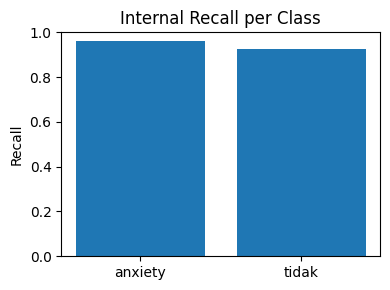

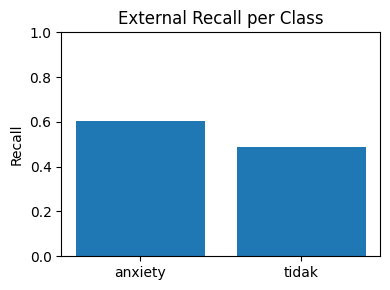

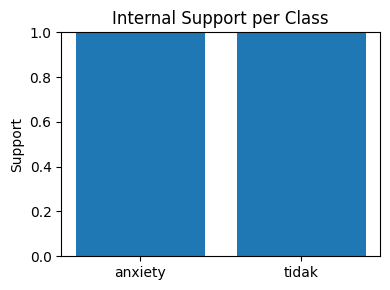

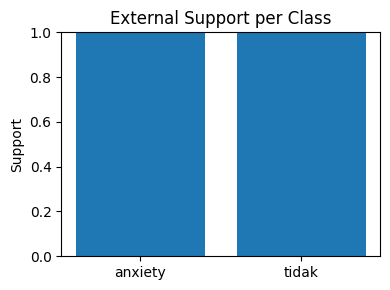

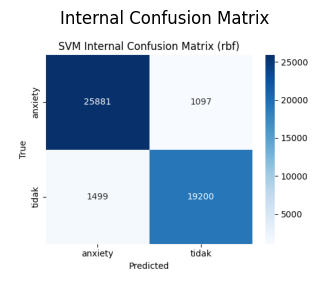

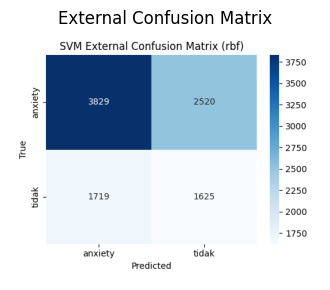


=== FINAL METRIC SUMMARY ===
INTERNAL:
         precision    recall  f1-score
anxiety   0.945252  0.959337  0.952243
tidak     0.945953  0.927581  0.936677

EXTERNAL:
         precision    recall  f1-score
anxiety   0.690159  0.603087  0.643692
tidak     0.392039  0.485945  0.433970


In [42]:
visualize_svm_results(
    "models/svm_all/flatten/"
)

#### Quadran SVM

In [43]:
train_svm_group_merged(
    csv_path="dataset/features_grouped/merged/svm_quadran_all.csv",
    out_dir="models/svm_all/quadran/",
    kernel="rbf",
    n_external=2
)

📊 SUBJECT STATS: {'balanced_per_class': 53, 'train_per_class': 51, 'external_per_class': 2}
✅ TRAINING + EXTERNAL TEST DONE (MERGED)
📁 Output: models/svm_all/quadran/


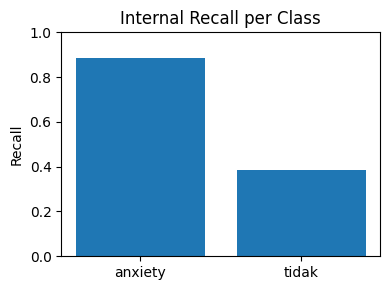

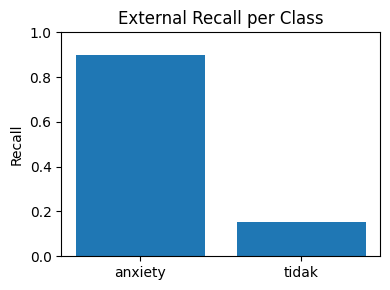

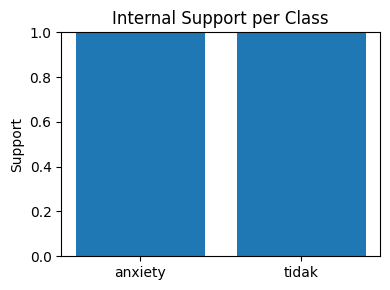

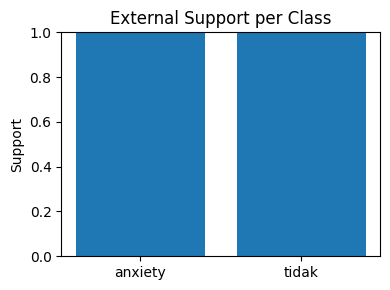

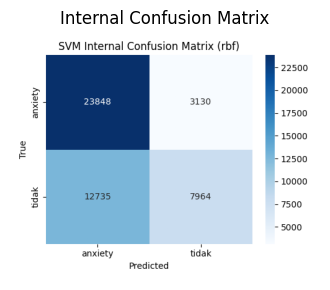

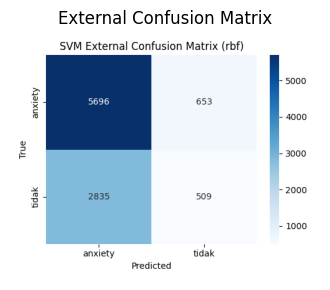


=== FINAL METRIC SUMMARY ===
INTERNAL:
         precision    recall  f1-score
anxiety   0.651887  0.883980  0.750397
tidak     0.717866  0.384753  0.500991

EXTERNAL:
         precision    recall  f1-score
anxiety   0.667683  0.897149  0.765591
tidak     0.438038  0.152213  0.225921


In [44]:
visualize_svm_results(
    "models/svm_all/quadran/"
)

## TESTING MODELS SVM

In [14]:
import pandas as pd
import joblib
from pathlib import Path


DROP_COLS = ["label", "condition", "subject", "question", "device", "frame"]


def svm_test(
    feature_path: str,
    model_dir: str,
):
    """
    feature_path : path ke .xlsx fitur (flatten / quadran bebas)
    model_dir    : folder yg berisi svm_model.joblib, scaler.joblib, label_encoder.joblib
    """

    feature_path = Path(feature_path)
    model_dir = Path(model_dir)

    # =========================
    # LOAD DATA
    # =========================
    df = pd.read_excel(feature_path)

    X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

    # =========================
    # LOAD MODEL
    # =========================
    svm_model = joblib.load(model_dir / "svm_model.joblib")
    scaler = joblib.load(model_dir / "scaler.joblib")
    label_encoder = joblib.load(model_dir / "label_encoder.joblib")

    # =========================
    # PREPROCESS
    # =========================
    X_scaled = scaler.transform(X)

    # =========================
    # PREDICT
    # =========================
    y_pred = svm_model.predict(X_scaled)
    y_label = label_encoder.inverse_transform(y_pred)

    # =========================
    # OUTPUT
    # =========================
    result = df.copy()
    result["svm_prediction"] = y_label
    result["svm_anxiety"] = (result["svm_prediction"] == "anxiety").astype(int)

    return result


In [23]:
def svm_decision(result_df, threshold=0.5):
    """
    result_df : output dari svm_test()
    threshold : proporsi minimum anxiety untuk dianggap anxiety
                default 0.5 = majority voting
    """

    total = len(result_df)
    anxiety_count = result_df["svm_anxiety"].sum()
    ratio = anxiety_count / total

    final_label = "anxiety" if ratio >= threshold else "tidak"

    return {
        "final_prediction": final_label,
        "anxiety_frames": int(anxiety_count),
        "total_frames": int(total),
        "anxiety_ratio": round(ratio, 3)
    }


In [55]:
def summarize_svm_result(name, res, gt_label, feature_type, svm_model):
    decision = svm_decision(res)
    return {
        "file": name,
        "feature_type": feature_type,   # POC-ABS Flatten / Quadran
        "svm_model": svm_model,         # flatten_balanced / quadran_balanced
        "ground_truth": gt_label,
        "final_prediction": decision["final_prediction"],
        "anxiety_ratio": decision["anxiety_ratio"],
        "correct": decision["final_prediction"] == gt_label
    }


**False**

In [46]:
res = svm_test(
    feature_path="./testing/features/before/anxiety/ananda_satria_putra_nugraha_1765167942203/poc_abs_flatten.xlsx",
    model_dir="./models/svm_before/flatten_balanced"
)

decision = svm_decision(res)
decision


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersi

{'final_prediction': 'tidak',
 'anxiety_frames': 224,
 'total_frames': 1035,
 'anxiety_ratio': np.float64(0.216)}

**True**

In [47]:
res = svm_test(
    feature_path="./testing/features/before/anxiety/nahdia_putri_safira_1765171578941/poc_abs_flatten.xlsx",
    model_dir="./models/svm_before/flatten_balanced"
)

decision = svm_decision(res)
decision

/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersi

{'final_prediction': 'anxiety',
 'anxiety_frames': 822,
 'total_frames': 822,
 'anxiety_ratio': np.float64(1.0)}

**True**

In [50]:
res = svm_test(
    feature_path="./testing/features/before/tidak/nabeel_nizam_1765258452319/poc_abs_flatten.xlsx",
    model_dir="./models/svm_before/flatten_balanced"
)

decision = svm_decision(res)
decision

/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersi

{'final_prediction': 'tidak',
 'anxiety_frames': 9,
 'total_frames': 582,
 'anxiety_ratio': np.float64(0.015)}

### Quadran

**True**

In [28]:
res = svm_test(
    feature_path="./testing/features/before/anxiety/ananda_satria_putra_nugraha_1765167942203/poc_abs_quadran_sum.xlsx",
    model_dir="./models/svm_before/quadran_balanced/"
)

decision = svm_decision(res)
decision


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersi

{'final_prediction': 'anxiety',
 'anxiety_frames': 155,
 'total_frames': 246,
 'anxiety_ratio': np.float64(0.63)}

**True**

In [48]:
res = svm_test(
    feature_path="./testing/features/before/anxiety/nahdia_putri_safira_1765171578941/poc_abs_quadran_sum.xlsx",
    model_dir="./models/svm_before/quadran_balanced/"
)

decision = svm_decision(res)
decision

/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersi

{'final_prediction': 'anxiety',
 'anxiety_frames': 753,
 'total_frames': 822,
 'anxiety_ratio': np.float64(0.916)}

**True**

In [52]:
res = svm_test(
    feature_path="./testing/features/before/tidak/nabeel_nizam_1765258452319/poc_abs_quadran_sum.xlsx",
    model_dir="./models/svm_before/quadran_balanced/"
)

decision = svm_decision(res)
decision

/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersi

{'final_prediction': 'tidak',
 'anxiety_frames': 189,
 'total_frames': 582,
 'anxiety_ratio': np.float64(0.325)}

In [56]:
rows = []

# ===== FLATTEN (POC-ABS Flatten + SVM Flatten Balanced) =====
res = svm_test(
    "./testing/features/before/anxiety/ananda_satria_putra_nugraha_1765167942203/poc_abs_flatten.xlsx",
    "./models/svm_before/flatten_balanced"
)
rows.append(
    summarize_svm_result(
        name="ananda_satria_putra_nugraha",
        res=res,
        gt_label="anxiety",
        feature_type="POC-ABS Flatten",
        svm_model="SVM Flatten Balanced"
    )
)

res = svm_test(
    "./testing/features/before/anxiety/nahdia_putri_safira_1765171578941/poc_abs_flatten.xlsx",
    "./models/svm_before/flatten_balanced"
)
rows.append(
    summarize_svm_result(
        name="nahdia_putri_safira",
        res=res,
        gt_label="anxiety",
        feature_type="POC-ABS Flatten",
        svm_model="SVM Flatten Balanced"
    )
)

res = svm_test(
    "./testing/features/before/tidak/nabeel_nizam_1765258452319/poc_abs_flatten.xlsx",
    "./models/svm_before/flatten_balanced"
)
rows.append(
    summarize_svm_result(
        name="nabeel_nizam",
        res=res,
        gt_label="tidak",
        feature_type="POC-ABS Flatten",
        svm_model="SVM Flatten Balanced"
    )
)

# ===== QUADRAN (POC-ABS Quadran + SVM Quadran Balanced) =====
res = svm_test(
    "./testing/features/before/anxiety/ananda_satria_putra_nugraha_1765167942203/poc_abs_quadran_sum.xlsx",
    "./models/svm_before/quadran_balanced"
)
rows.append(
    summarize_svm_result(
        name="ananda_satria_putra_nugraha",
        res=res,
        gt_label="anxiety",
        feature_type="POC-ABS Quadran",
        svm_model="SVM Quadran Balanced"
    )
)

res = svm_test(
    "./testing/features/before/anxiety/nahdia_putri_safira_1765171578941/poc_abs_quadran_sum.xlsx",
    "./models/svm_before/quadran_balanced"
)
rows.append(
    summarize_svm_result(
        name="nahdia_putri_safira",
        res=res,
        gt_label="anxiety",
        feature_type="POC-ABS Quadran",
        svm_model="SVM Quadran Balanced"
    )
)

res = svm_test(
    "./testing/features/before/tidak/nabeel_nizam_1765258452319/poc_abs_quadran_sum.xlsx",
    "./models/svm_before/quadran_balanced"
)
rows.append(
    summarize_svm_result(
        name="nabeel_nizam",
        res=res,
        gt_label="tidak",
        feature_type="POC-ABS Quadran",
        svm_model="SVM Quadran Balanced"
    )
)

summary_df = pd.DataFrame(rows)
summary_df


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersi

,file,feature_type,svm_model,ground_truth,final_prediction,anxiety_ratio,correct
0,ananda_satria_putra_nugraha,POC-ABS Flatten,SVM Flatten Balanced,anxiety,tidak,0.216,False
1,nahdia_putri_safira,POC-ABS Flatten,SVM Flatten Balanced,anxiety,anxiety,1.000,True
2,nabeel_nizam,POC-ABS Flatten,SVM Flatten Balanced,tidak,tidak,0.015,True
3,ananda_satria_putra_nugraha,POC-ABS Quadran,SVM Quadran Balanced,anxiety,anxiety,0.849,True
4,nahdia_putri_safira,POC-ABS Quadran,SVM Quadran Balanced,anxiety,anxiety,0.916,True
5,nabeel_nizam,POC-ABS Quadran,SVM Quadran Balanced,tidak,tidak,0.325,True


# Visualisasi Grafik

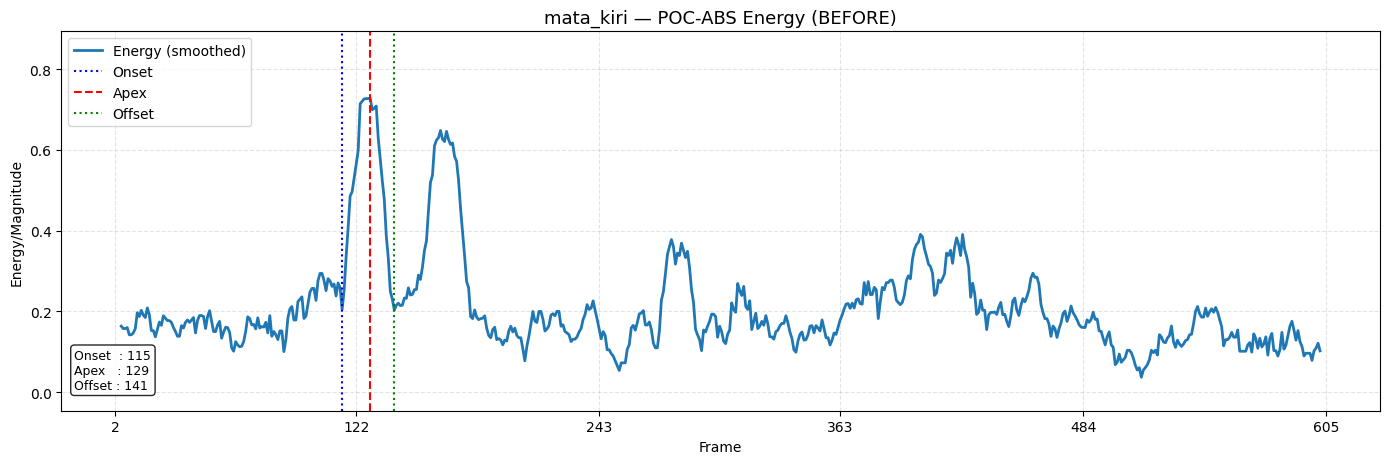

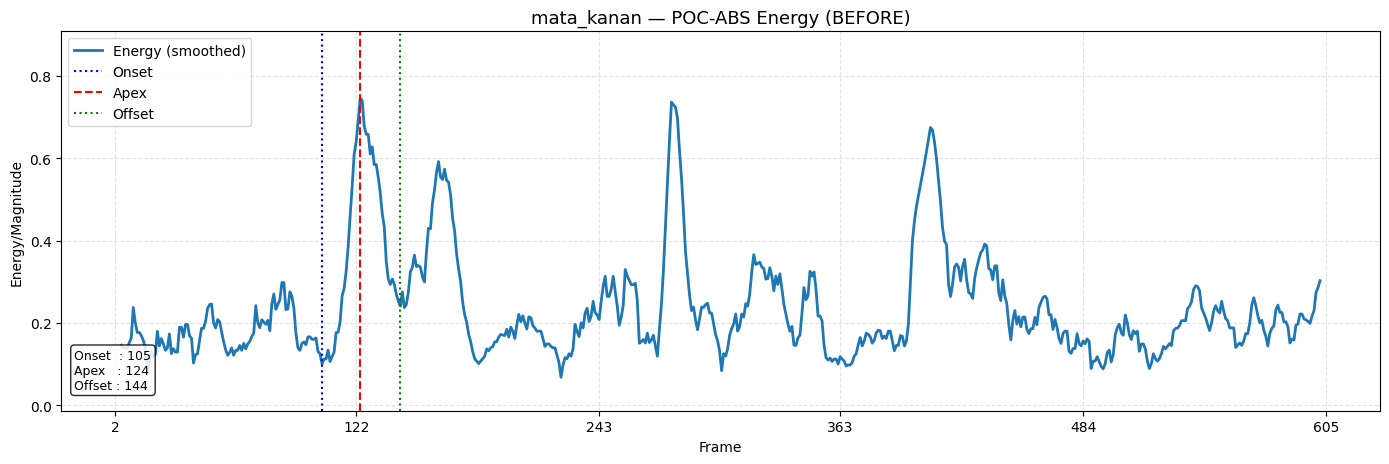

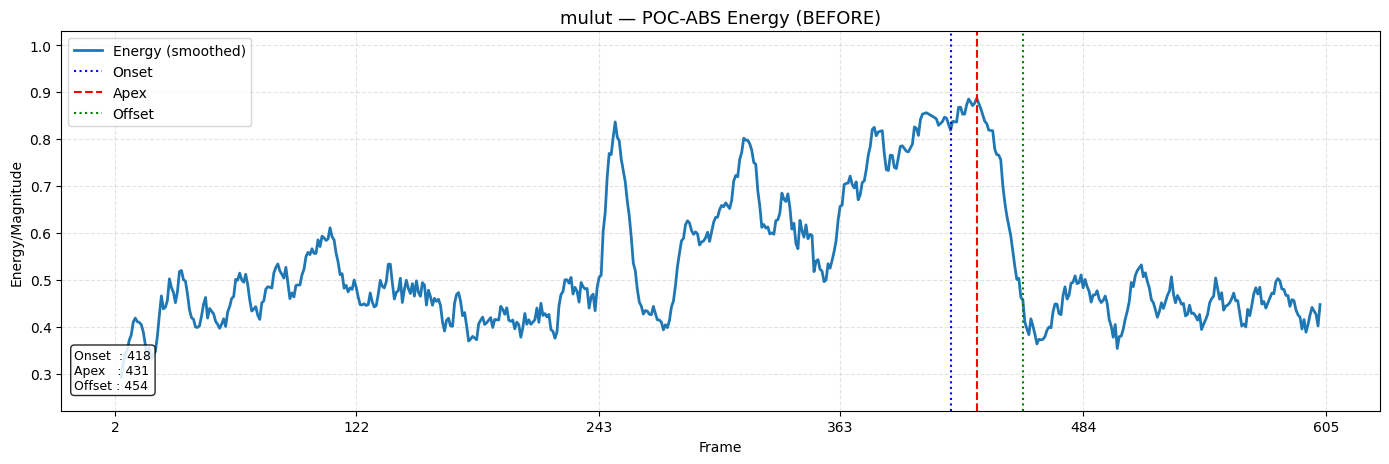

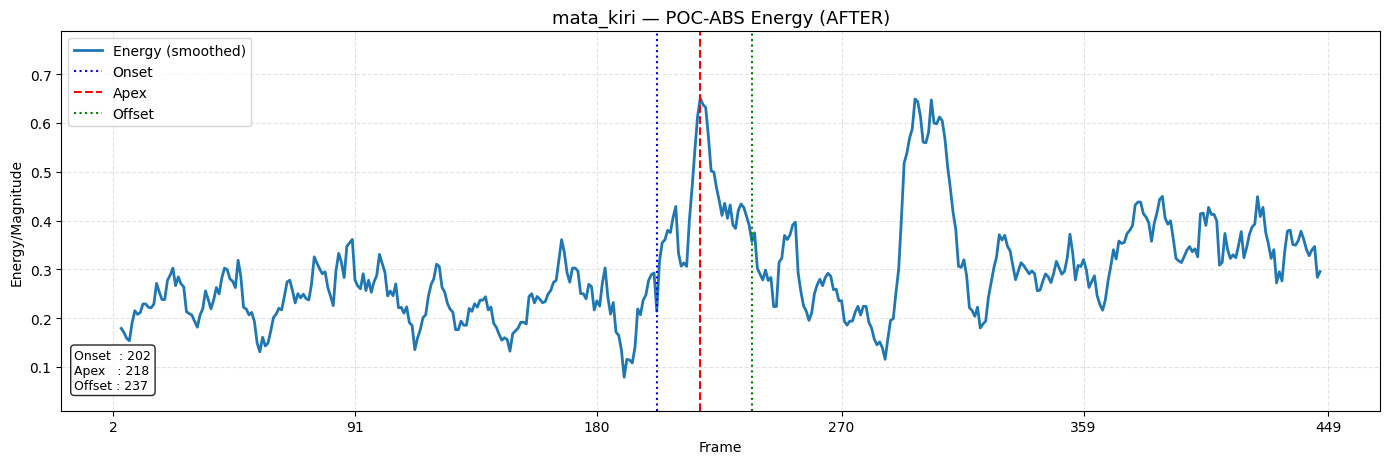

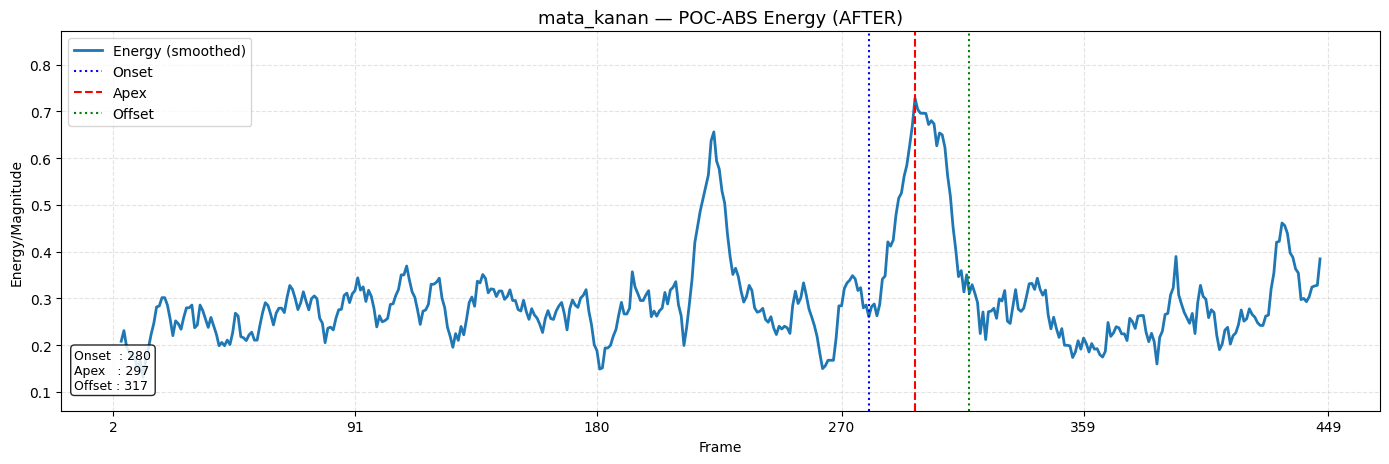

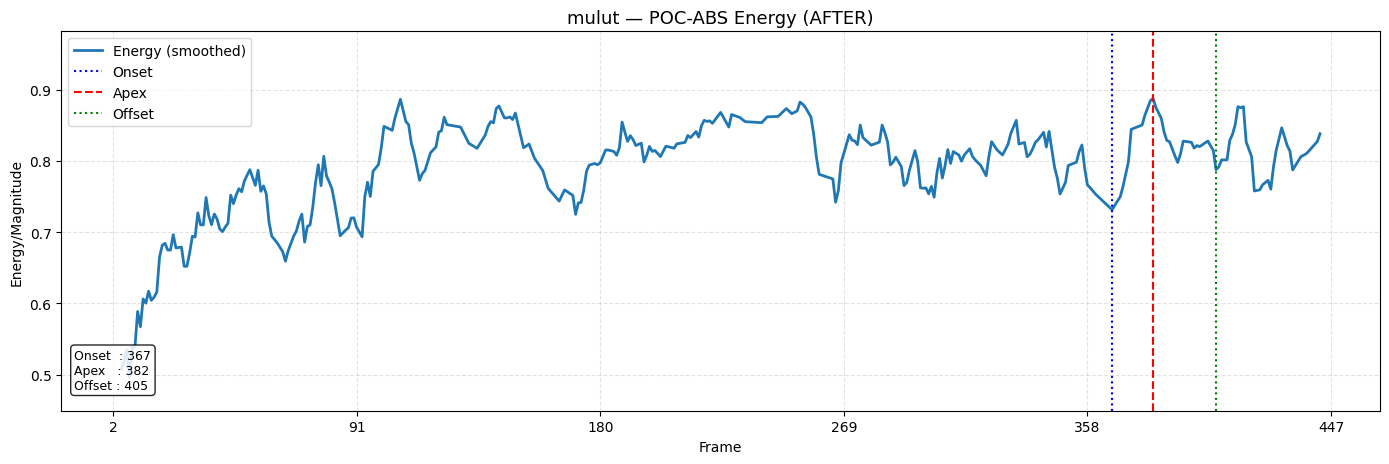

✅ O–A–O disimpan ke: dataset/feature_output/onset_apex_offset.csv


In [ ]:
# ==================================================
# KONFIGURASI UTAMA
# ==================================================
DATA_FILE = "dataset/feature_output/poc_abs_timeseries.xlsx"
OUTPUT_OAO = "dataset/feature_output/onset_apex_offset.csv"

SUBJECT  = "nahdia"
QUESTION = "q4"
DEVICE   = "device_sec"

SMOOTH_WINDOW  = 7      # smoothing temporal (noise reduction)
BLINK_QUANTILE = 0.95   # buang spike ekstrem (blink candidate)
EVENT_WINDOW   = 20     # window lokal sekitar apex

COMPONENTS  = ["mata_kiri", "mata_kanan", "mulut"]
XTICK_COUNT = 6

# ==================================================
# LOAD & FILTER DATA
# ==================================================
df = pd.read_excel(DATA_FILE)
df = df[
    (df["subject"] == SUBJECT) &
    (df["question"] == QUESTION) &
    (df["device"] == DEVICE)
]

# ==================================================
# HITUNG ENERGY POC-ABS
# Energy = magnitudo vektor (dx, dy)
# ==================================================
energy_df = (
    df.groupby(["label", "component", "frame"])["magnitude"]
    .mean()
    .reset_index()
)

energy_df = energy_df.rename(columns={"magnitude": "energy"})

# ==================================================
# BLINK FILTER (OUTLIER GLOBAL)
# ==================================================
blink_thr = energy_df["energy"].quantile(BLINK_QUANTILE)
energy_df = energy_df[energy_df["energy"] < blink_thr]

# ==================================================
# STORAGE HASIL O–A–O
# ==================================================
oao_records = []

# ==================================================
# EVENT-CENTERED O–A–O + VISUALISASI
# ==================================================
def plot_energy_oao_per_roi(condition):
    for comp in COMPONENTS:

        sub = energy_df[
            (energy_df["label"] == condition) &
            (energy_df["component"] == comp)
        ].sort_values("frame").reset_index(drop=True)

        if sub.empty:
            continue

        # smoothing temporal
        smooth = sub["energy"].rolling(
            window=SMOOTH_WINDOW,
            center=True
        ).mean()

        if smooth.dropna().empty:
            continue

        # --------------------------------------------------
        # APEX: puncak energi global (setelah smoothing)
        # --------------------------------------------------
        apex_idx   = smooth.idxmax()
        apex_frame = int(sub.loc[apex_idx, "frame"])
        apex_pos   = sub.index.get_loc(apex_idx)

        # --------------------------------------------------
        # ONSET & OFFSET: minimum lokal di sekitar apex
        # --------------------------------------------------
        left  = smooth.iloc[max(0, apex_pos - EVENT_WINDOW):apex_pos]
        right = smooth.iloc[apex_pos + 1:apex_pos + EVENT_WINDOW + 1]

        if left.dropna().empty or right.dropna().empty:
            continue

        onset_idx  = left.idxmin()
        offset_idx = right.idxmin()

        onset_frame  = int(sub.loc[onset_idx, "frame"])
        offset_frame = int(sub.loc[offset_idx, "frame"])

        # simpan hasil
        oao_records.append({
            "subject": SUBJECT,
            "label": condition,
            "question": QUESTION,
            "device": DEVICE,
            "component": comp,
            "onset_frame": onset_frame,
            "apex_frame": apex_frame,
            "offset_frame": offset_frame
        })

        # ==================================================
        # VISUALISASI FULL SIGNAL + O–A–O
        # ==================================================
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.set_title(
            f"{comp} — POC-ABS Energy ({condition.upper()})",
            fontsize=13
        )

        ax.plot(
            sub["frame"],
            smooth,
            linewidth=2,
            label="Energy (smoothed)"
        )

        ax.axvline(onset_frame,  color="blue",  linestyle=":",  linewidth=1.5, label="Onset")
        ax.axvline(apex_frame,   color="red",   linestyle="--", linewidth=1.5, label="Apex")
        ax.axvline(offset_frame, color="green", linestyle=":",  linewidth=1.5, label="Offset")

        # scale Y agar tidak terlihat terlalu runcing
        y_min = np.nanmin(smooth)
        y_max = np.nanmax(smooth)
        y_pad = 0.12 * (y_max - y_min)
        ax.set_ylim(y_min - y_pad, y_max + 2 * y_pad)

        # info ringkas O–A–O
        ax.text(
            0.01, 0.05,
            f"Onset  : {onset_frame}\n"
            f"Apex   : {apex_frame}\n"
            f"Offset : {offset_frame}",
            transform=ax.transAxes,
            ha="left", va="bottom", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
        )

        # sumbu X tetap frame asli (bukan indeks)
        xmin, xmax = sub["frame"].min(), sub["frame"].max()
        ax.set_xticks(np.linspace(xmin, xmax, XTICK_COUNT, dtype=int))

        ax.set_xlabel("Frame")
        ax.set_ylabel("Energy/Magnitude")
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.legend(loc="upper left")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

# ==================================================
# RUN PIPELINE
# ==================================================
plot_energy_oao_per_roi("before")
plot_energy_oao_per_roi("after")

pd.DataFrame(oao_records).to_csv(OUTPUT_OAO, index=False)
print("✅ O–A–O disimpan ke:", OUTPUT_OAO)


In [57]:
def visualize_motion_vectors(frame1_path, frameX_path, apex_frame,blockSize=7, output_path='motion_vector.jpg'):
    import cv2
    import matplotlib.pyplot as plt
    from feature_extraction.poc import POC
    from feature_extraction.vektor import Vektor

    frame1 = cv2.imread(frame1_path, cv2.IMREAD_GRAYSCALE)
    frameX = cv2.imread(frameX_path, cv2.IMREAD_GRAYSCALE)

    if frame1 is None or frameX is None:
        raise ValueError("Gagal membaca frame")

    if frame1.shape != frameX.shape:
        frameX = cv2.resize(frameX, (frame1.shape[1], frame1.shape[0]))

    # === POC ===
    poc = POC(frame1, frameX, blockSize)
    poc_val = poc.getPOC()

    # === VEKTOR ===
    vec = Vektor(poc_val, blockSize)
    vec_data = vec.getVektor()   # [x, y, dx, dy]

    plt.figure(figsize=(18,6))

    # Frame 1
    plt.subplot(1,3,1)
    plt.imshow(frame1, cmap='gray')
    plt.title("Frame 1 (Reference)")
    plt.axis('off')

    # Frame X
    plt.subplot(1,3,2)
    plt.imshow(frameX, cmap='gray')
    plt.title(f"Frame {apex_frame} (Comparison)")
    plt.axis('off')

    # Vector visualization
    plt.subplot(1,3,3)
    plt.imshow(frame1, cmap='gray')
    plt.title("POC-ABS Motion Vectors")
    plt.axis('off')

    h, w = frame1.shape

    # grid
    for x in range(0, w, blockSize):
        plt.axvline(x, color='lime', linewidth=0.5)
    for y in range(0, h, blockSize):
        plt.axhline(y, color='lime', linewidth=0.5)

    # quiver
    X, Y, U, V = [], [], [], []
    for v in vec_data:
        if v[2] != 0 or v[3] != 0:
            X.append(v[0])
            Y.append(v[1])
            U.append(v[2])
            V.append(v[3])

    plt.quiver(X, Y, U, V, color='red', scale=1, scale_units='xy')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()


Onset : dataset/roi_images/nahdia/before/q4/device_sec/mata_kanan/img0105.jpg
Apex  : dataset/roi_images/nahdia/before/q4/device_sec/mata_kanan/img0124.jpg


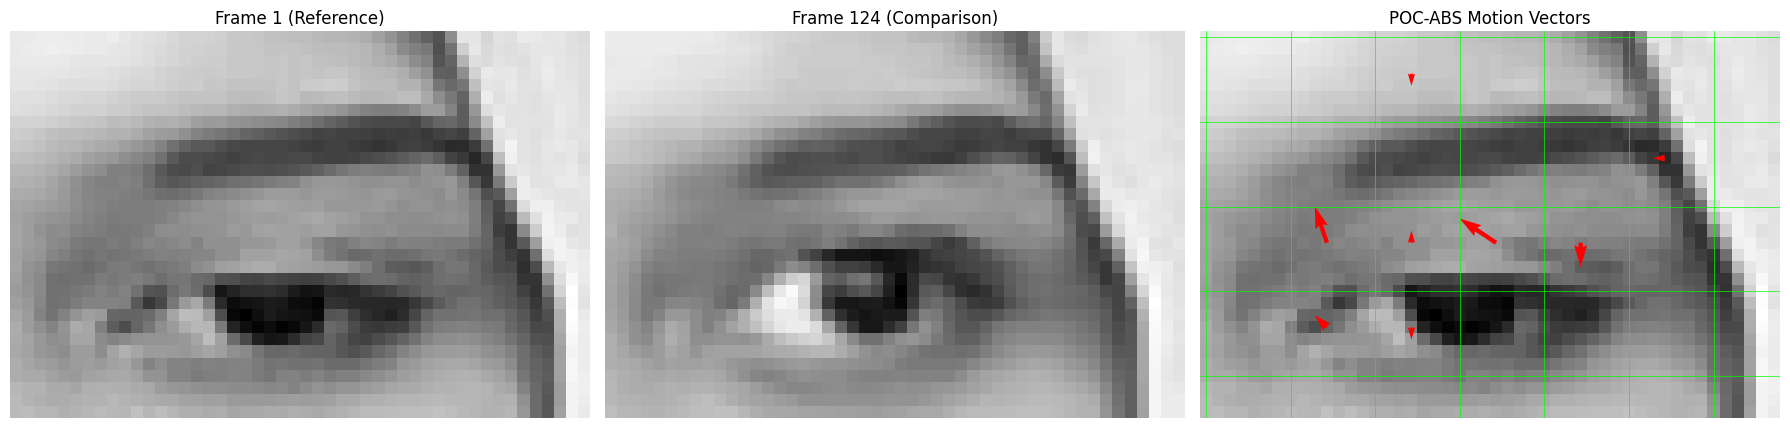

In [79]:
import os
import pandas as pd

ROI_BASE = "dataset/roi_images"
OAO_FILE = "dataset/feature_output/onset_apex_offset.csv"

SUBJECT   = "nahdia"
LABEL     = "before"
QUESTION  = "q4"
DEVICE    = "device_sec"
COMPONENT = "mata_kanan"

BLOCK_SIZE = 7

# --------------------------------------------------
# Load O–A–O result
# --------------------------------------------------
oao = pd.read_csv(OAO_FILE)

row = oao[
    (oao["subject"] == SUBJECT) &
    (oao["label"] == LABEL) &
    (oao["question"] == QUESTION) &
    (oao["device"] == DEVICE) &
    (oao["component"] == COMPONENT)
].iloc[0]

onset_frame = int(row["onset_frame"])
apex_frame  = int(row["apex_frame"])

# --------------------------------------------------
# Build path & visualize
# --------------------------------------------------
roi_path = os.path.join(
    ROI_BASE,
    SUBJECT,
    LABEL,
    QUESTION,
    DEVICE,
    COMPONENT
)

frame1_path = os.path.join(roi_path, f"img{onset_frame:04d}.jpg")
frameX_path = os.path.join(roi_path, f"img{apex_frame:04d}.jpg")

print("Onset :", frame1_path)
print("Apex  :", frameX_path)

visualize_motion_vectors(
    frame1_path=frame1_path,
    frameX_path=frameX_path,
    apex_frame=apex_frame,
    blockSize=BLOCK_SIZE,
    output_path=f"oao_{SUBJECT}_{LABEL}_{QUESTION}_{DEVICE}_{COMPONENT}.jpg"
)


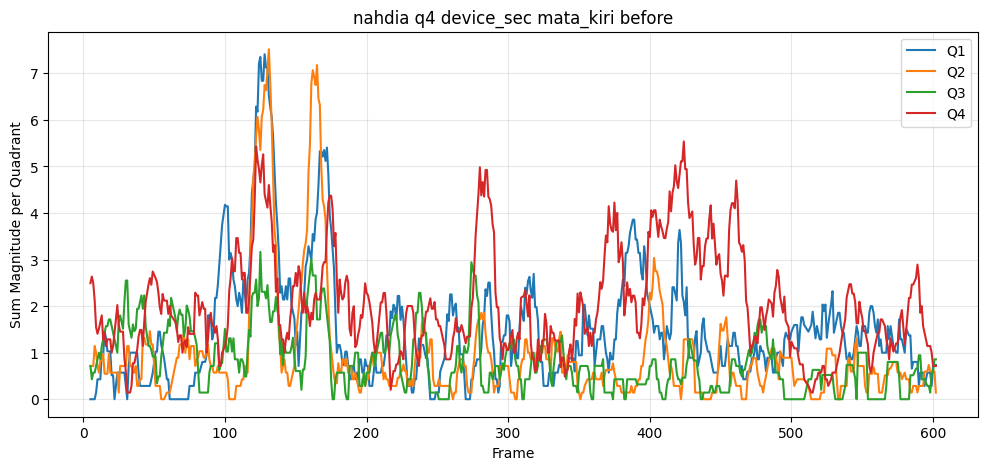

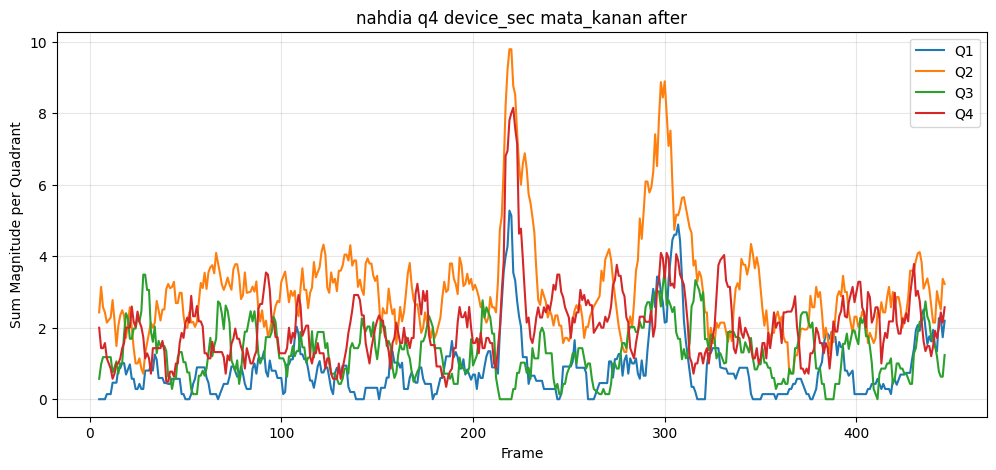

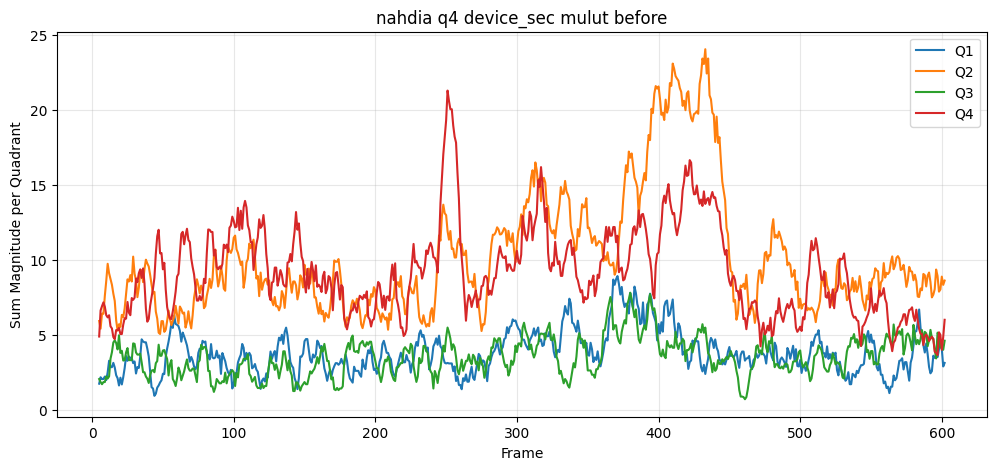

In [ ]:
# 2) 4QMV per frame (sum magnitude per kuadran) dan plot Q1..Q4
def compute_4qmv(df):
    df2 = df.copy()
    df2 = df2[df2.quadran.str.startswith("Q")]  # filter
    agg = df2.groupby(["subject","question","device","label","component","frame","quadran"])["magnitude"].sum().reset_index()
    pivot = agg.pivot_table(index=["subject","question","device","label","component","frame"],
                            columns="quadran", values="magnitude", fill_value=0).reset_index()
    # ensure Q1..Q4 exist
    for q in ["Q1","Q2","Q3","Q4"]:
        if q not in pivot.columns:
            pivot[q] = 0
    return pivot

pivot = compute_4qmv(df)

def plot_4qmv(subject, question, device, component, label="before"):
    p = pivot[
        (pivot.subject==subject)&(pivot.question==question)&(pivot.device==device)&
        (pivot.component==component)&(pivot.label==label)
    ].sort_values("frame")
    if p.empty:
        print("No 4QMV rows")
        return
    plt.figure(figsize=(12,5))
    for q in ["Q1","Q2","Q3","Q4"]:
        plt.plot(p.frame, p[q].rolling(window=7,center=True).mean(), label=q)
    plt.xlabel("Frame"); plt.ylabel("Sum Magnitude per Quadrant"); plt.title(f"{subject} {question} {device} {component} {label}")
    plt.legend(); plt.grid(alpha=0.3); plt.show()

plot_4qmv("nahdia", "q4", "device_sec", "mata_kiri", "before")
plot_4qmv("nahdia", "q4", "device_sec", "mata_kanan", "after")
plot_4qmv("nahdia", "q4", "device_sec", "mulut", "before")

In [ ]:
#code untuk mencari confussion matrix
from clasification.svm import SVMClassifier
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# Load the dataset and initialize the classifier
dataset_file = 'output-baru/csv/nilai-fitur-all-filtered.csv'
label_column = 'Label'
except_feature_columns = ['Frame', 'Folder Path', 'Label']  # Columns to exclude

# Load the data first to handle NaN values
data = pd.read_csv(dataset_file)

# Check for NaN values
print(f"NaN values before imputation: {data.isna().sum().sum()}")

# Option 1: Drop rows with NaN values
# data = data.dropna()

# Option 2: Impute NaN values with mean (recommended)
features = [col for col in data.columns if col not in except_feature_columns]
imputer = SimpleImputer(strategy='mean')
data[features] = imputer.fit_transform(data[features])

# Verify NaN values are gone
print(f"NaN values after imputation: {data.isna().sum().sum()}")

# Save the cleaned data or use it directly
cleaned_dataset_file = 'output-baru/csv/cleaned-nilai-fitur-all-component.csv'
data.to_csv(cleaned_dataset_file, index=False)

# Initialize the classifier with cleaned data
classifier = SVMClassifier(cleaned_dataset_file, label_column, except_feature_column=except_feature_columns)

# Load, split, train, evaluate and save the model
classifier.load_data()
classifier.split_data(test_size=0.2)
classifier.train_model(autoParams=True)
classifier.evaluate_model()
classifier.save_model('svm_model_random_sampling.joblib', 'label_encoder_random_sampling.joblib')

NaN values before imputation: 0
NaN values after imputation: 0
output-baru/csv/cleaned-nilai-fitur-all-component.csv


In [ ]:
#code svm random sampling sebelum 4qmv/nilai asli (Tanpa Seleksi Fitur)
import os
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report

# 0. Pastikan folder models/ ada
if not os.path.exists('models'):
    os.makedirs('models')

# 1. Load dataset
df = pd.read_csv('output-baru/csv/nilai-fitur-all-filtered-anxiety.csv')

# 2. Siapkan fitur dan label
X = df.drop(columns=['Frame', 'Folder Path', 'Label']) # x:semua kolom fitur kecuali frame, folder path dan label
y = df['Label'] # label target (tinggi, rendah, dst)

# 3. Encode label
label_encoder = LabelEncoder() # label tinggi, rendah, dst dikonversi menjadi angka (0,1,2,3) menggunakan LabelEncoder
y_encoded = label_encoder.fit_transform(y)

# 4. Split data: 80% train, 10% val, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42) #agar distribusi label seimbang

# 5. Scaling fitur
scaler = StandardScaler() #semua fitur diubah ke skala standar (mean 0, std dev=1)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 6. Daftar kernel yang akan diuji
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

best_model = None
best_kernel = None
best_accuracy = 0

# 7. Loop semua kernel
for kernel in kernels:
    print(f"\n Training dengan kernel: {kernel}")
    model = SVC(kernel=kernel, C=1)

    # Latih model
    model.fit(X_train_scaled, y_train)

    # Evaluasi pada validasi
    y_val_pred = model.predict(X_val_scaled)
    report = classification_report(y_val, y_val_pred, output_dict=True, target_names=label_encoder.classes_)
    accuracy = report['accuracy']

    print(f"\n=== VALIDATION REPORT for kernel '{kernel}' ===")
    print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))

    # Simpan model terbaik
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_kernel = kernel
        best_model = model

# 8. Evaluasi model terbaik pada data test
print(f"\n Kernel terbaik berdasarkan validasi: {best_kernel} (akurasi: {best_accuracy:.4f})")

y_test_pred = best_model.predict(X_test_scaled) # setelah kernel diuji, gunakan model dgn akurasi terbaik
print(f"\n=== TEST REPORT for best kernel '{best_kernel}' ===")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))

# 9. Simpan model, scaler, dan label encoder
joblib.dump(best_model, f'models/svm_model_{best_kernel}.joblib')
joblib.dump(scaler, 'models/scaler.joblib')
joblib.dump(label_encoder, 'models/label_encoder.joblib')

print(f"\n Model terbaik disimpan sebagai: models/svm_model_{best_kernel}.joblib")
print(f" Scaler disimpan sebagai: models/scaler.joblib") # standardisasi saat interface
print(f" LabelEncoder disimpan sebagai: models/label_encoder.joblib") # untuk konversi kembali dari angka ke label asli


🔍 Training dengan kernel: linear

=== VALIDATION REPORT for kernel 'linear' ===
               precision    recall  f1-score   support

       rendah       0.94      0.95      0.94      1359
sangat_rendah       0.97      0.96      0.97      1330
sangat_tinggi       0.93      0.94      0.94      1307
       tinggi       0.96      0.95      0.96      1349

     accuracy                           0.95      5345
    macro avg       0.95      0.95      0.95      5345
 weighted avg       0.95      0.95      0.95      5345


🔍 Training dengan kernel: rbf

=== VALIDATION REPORT for kernel 'rbf' ===
               precision    recall  f1-score   support

       rendah       0.99      0.98      0.98      1359
sangat_rendah       0.99      0.99      0.99      1330
sangat_tinggi       0.98      0.98      0.98      1307
       tinggi       0.97      0.99      0.98      1349

     accuracy                           0.98      5345
    macro avg       0.98      0.98      0.98      5345
 weighted avg 

📊 Jumlah fitur asli: 312
📈 Komponen untuk 95% variance: 224
📈 Komponen untuk 90% variance: 202


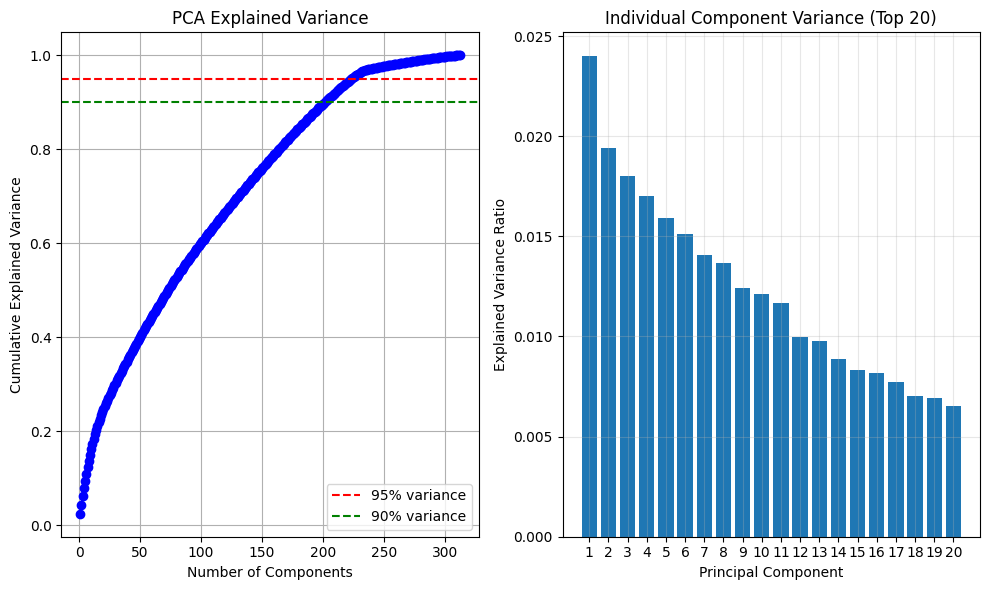

🔍 Testing PCA dengan komponen: [50, 100, 202, 224]

🔧 Testing PCA dengan 50 komponen
📊 Dimensi setelah PCA: 50
📈 Total explained variance: 0.4004

🔍 Training PCA(50) + SVM(linear)
  📊 Validation Accuracy: 0.9218

🔍 Training PCA(50) + SVM(rbf)
  📊 Validation Accuracy: 0.9826

🔍 Training PCA(50) + SVM(poly)
  📊 Validation Accuracy: 0.9744

🔍 Training PCA(50) + SVM(sigmoid)
  📊 Validation Accuracy: 0.7411

🔧 Testing PCA dengan 100 komponen
📊 Dimensi setelah PCA: 100
📈 Total explained variance: 0.6008

🔍 Training PCA(100) + SVM(linear)
  📊 Validation Accuracy: 0.9349

🔍 Training PCA(100) + SVM(rbf)
  📊 Validation Accuracy: 0.9843

🔍 Training PCA(100) + SVM(poly)
  📊 Validation Accuracy: 0.9695

🔍 Training PCA(100) + SVM(sigmoid)
  📊 Validation Accuracy: 0.8114

🔧 Testing PCA dengan 202 komponen
📊 Dimensi setelah PCA: 202
📈 Total explained variance: 0.9017

🔍 Training PCA(202) + SVM(linear)
  📊 Validation Accuracy: 0.9433

🔍 Training PCA(202) + SVM(rbf)
  📊 Validation Accuracy: 0.9841

🔍 Tr

In [ ]:
#code untuk seleksi fitur PCA non-4qmv
import os
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report

# 0. Pastikan folder models/ ada
if not os.path.exists('models'):
    os.makedirs('models')

# 1. Load dataset
df = pd.read_csv('output-baru/csv/nilai-fitur-all-filtered-anxiety.csv')

# 2. Siapkan fitur dan label
X = df.drop(columns=['Frame', 'Folder Path', 'Label']) # x: hanya fitur numerik untuk training
y = df['Label'] # y: label tingkat kecemasan

print(f" Jumlah fitur asli: {X.shape[1]}")

# 3. Encode label
label_encoder = LabelEncoder() # label tinggi, rendah, dst dikonversi menjadi angka (0,1,2,3) menggunakan LabelEncoder
y_encoded = label_encoder.fit_transform(y)

# 4. Split data: 80% train, 10% val, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# 5. Scaling fitur (WAJIB sebelum PCA)
scaler = StandardScaler() # PCA sangat sensitif terhadap skala fitur → harus distandardisasi (mean=0, std=1).
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 6. ========== ANALISIS PCA ==========
# Pertama, analisis berapa komponen yang optimal
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Hitung cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_) # digunakan untuk melihat akumulasi variance

# Tentukan jumlah komponen untuk 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f" Komponen untuk 95% variance: {n_components_95}")

# Tentukan jumlah komponen untuk 90% variance
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"📈 Komponen untuk 90% variance: {n_components_90}")

# Plot explained variance (opsional, bisa di-comment jika tidak perlu)
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.bar(range(1, min(21, len(pca_full.explained_variance_ratio_) + 1)),
         pca_full.explained_variance_ratio_[:20])
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Individual Component Variance (Top 20)')
plt.xticks(range(1, min(21, len(pca_full.explained_variance_ratio_) + 1)))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/pca_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. ========== TESTING BERBAGAI JUMLAH KOMPONEN PCA ==========
# Test beberapa opsi komponen PCA
pca_options = [
    n_components_90,  # 90% variance
    n_components_95,  # 95% variance
    min(50, X.shape[1]),  # Maksimal 50 komponen
    min(100, X.shape[1])  # Maksimal 100 komponen
]

# Hapus duplikat dan urutkan
pca_options = sorted(list(set(pca_options)))
print(f" Testing PCA dengan komponen: {pca_options}")

kernels = ['linear', 'rbf', 'poly', 'sigmoid']

best_model = None
best_kernel = None
best_pca_components = None
best_accuracy = 0
best_pca = None

results = []

# 8. Loop untuk setiap kombinasi PCA + kernel
for n_components in pca_options: # untuk setiap jumlah komponen PCA, diuji kombinasi kernelnya
    print(f"\n{'='*50}")
    print(f" Testing PCA dengan {n_components} komponen")

    # Inisialisasi PCA
    pca = PCA(n_components=n_components)

    # Fit PCA pada training data dan transform semua data
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    print(f" Dimensi setelah PCA: {X_train_pca.shape[1]}")
    print(f" Total explained variance: {pca.explained_variance_ratio_.sum():.4f}")

    # Test setiap kernel dengan PCA ini
    for kernel in kernels:
        print(f"\n🔍 Training PCA({n_components}) + SVM({kernel})")

        # Train model
        model = SVC(kernel=kernel, C=1, random_state=42)
        model.fit(X_train_pca, y_train)

        # Evaluasi pada validasi
        y_val_pred = model.predict(X_val_pca) # setelah mendapat kombinasi terbaik PCA + SVM diuji ke data test
        report = classification_report(y_val, y_val_pred, output_dict=True,
                                     target_names=label_encoder.classes_)
        accuracy = report['accuracy']

        print(f"   Validation Accuracy: {accuracy:.4f}")

        # Simpan hasil
        results.append({
            'pca_components': n_components,
            'kernel': kernel,
            'accuracy': accuracy,
            'explained_variance': pca.explained_variance_ratio_.sum()
        })

        # Update model terbaik
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_kernel = kernel
            best_pca_components = n_components
            best_model = model
            best_pca = pca

# 9. ========== HASIL TERBAIK ==========
print(f"\n{'='*60}")
print(f" KONFIGURASI TERBAIK:")
print(f"    PCA Components: {best_pca_components}")
print(f"    SVM Kernel: {best_kernel}")
print(f"    Validation Accuracy: {best_accuracy:.4f}")
print(f"    Explained Variance: {best_pca.explained_variance_ratio_.sum():.4f}")

# Transform test data dengan PCA terbaik
X_test_pca_best = best_pca.transform(X_test_scaled)

# Evaluasi final pada test data
y_test_pred = best_model.predict(X_test_pca_best)
print(f"\n=== FINAL TEST REPORT ===")
print(f"PCA Components: {best_pca_components}, Kernel: {best_kernel}")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))

# 10. ========== SIMPAN MODEL DAN HASIL ==========
# Simpan model terbaik beserta PCA
joblib.dump(best_model, f'models/svm_pca_model_{best_kernel}_{best_pca_components}comp.joblib')
joblib.dump(best_pca, f'models/pca_{best_pca_components}comp.joblib')
joblib.dump(scaler, 'models/scaler.joblib')
joblib.dump(label_encoder, 'models/label_encoder.joblib')

# Simpan hasil semua eksperimen
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('accuracy', ascending=False)
results_df.to_csv('models/pca_svm_results.csv', index=False)

print(f"\n SAVED FILES:")
print(f"    Best Model: models/svm_pca_model_{best_kernel}_{best_pca_components}comp.joblib")
print(f"    Best PCA: models/pca_{best_pca_components}comp.joblib")
print(f"    Scaler: models/scaler.joblib")
print(f"    Label Encoder: models/label_encoder.joblib")
print(f"    All Results: models/pca_svm_results.csv")

# 11. ========== TAMPILKAN TOP 5 HASIL ==========
print(f"\n TOP 5 KOMBINASI TERBAIK:")
print(results_df.head().to_string(index=False))

# 12. ========== INFORMASI FITUR PENTING (untuk PCA terbaik) ==========
print(f"\n KOMPONEN PCA TERPENTING:")
feature_names = X.columns.tolist()
components_df = pd.DataFrame( # menampilkan fitur-fitur yg paling berkontribusi pada 3 komponen utama PCA
    best_pca.components_[:5],  # Top 5 komponen
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(5)]
)

# Tampilkan kontribusi fitur terbesar untuk setiap komponen
for i in range(min(3, best_pca.n_components_)):  # Top 3 komponen
    print(f"\n Principal Component {i+1} (variance: {best_pca.explained_variance_ratio_[i]:.4f}):")
    pc_contributions = abs(components_df.iloc[i]).sort_values(ascending=False).head(5)
    for feature, contribution in pc_contributions.items():
        print(f"   {feature}: {contribution:.4f}")

In [ ]:
import pandas as pd # manipulasi data
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder # preprocessing
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # evaluasi
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt # visualisasi
import seaborn as sns
import joblib # penyimpanan
import os

# Path ke file CSV
csv_path = "output-baru/csv/nilai-fitur-all-filtered-anxiety.csv"

print("="*60)
print("LINEAR DISCRIMINANT ANALYSIS (LDA) UNTUK SELEKSI FITUR")
print("="*60)

# Load data
print("\n1. LOADING DATA...")
try:
    df = pd.read_csv(csv_path)
    print(f" Data berhasil dimuat dengan shape: {df.shape}")
    print(f"   Kolom yang tersedia: {len(df.columns)} kolom")
except FileNotFoundError:
    print(f" File tidak ditemukan di path: {csv_path}")
    exit()

# Label sudah tersedia langsung di kolom 'Label'
print(f"\n2. DISTRIBUSI LABEL ANXIETY:")
label_counts = df['Label'].value_counts() # menampilkan jumlah sampel per label
for label, count in label_counts.items():
    print(f"   {label}: {count} sampel ({count/len(df)*100:.1f}%)")

# Encode label
label_encoder = LabelEncoder() # konversi label menjadi angka (0,1,2,dst)
df['Label_Encoded'] = label_encoder.fit_transform(df['Label'])

print(f"\n3. MAPPING LABEL:")
for i, label in enumerate(label_encoder.classes_):
    encoded_value = label_encoder.transform([label])[0]
    print(f"   {label} → {encoded_value}")

# Prepare features
columns_to_drop = ['Frame', 'Folder Path', 'Label', 'Label_Encoded'] # menghapus kolom yg tdk relevan sbg fitur dan menyimpan fitur ke x dan label ke y
X = df.drop(columns=columns_to_drop)
y = df['Label_Encoded']

print(f"\n4. PERSIAPAN DATA:")
print(f"   Jumlah fitur asli: {X.shape[1]}")
print(f"   Jumlah sampel: {X.shape[0]}")
print(f"   Jumlah kelas: {len(np.unique(y))}")

# Handle missing values
if X.isnull().sum().sum() > 0:
    print(f"   Mengisi {X.isnull().sum().sum()} missing values...")
    X = X.fillna(X.median()) # jika ada nilai kosong diisi nilai tengah

# Split data 80:10:10
print(f"\n5. SPLIT DATA (80:10:10)...")
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"   Training: {X_train.shape[0]} sampel")
print(f"   Validation: {X_val.shape[0]} sampel")
print(f"   Testing: {X_test.shape[0]} sampel")

# Standarisasi fitur
print(f"\n6. STANDARISASI FITUR...")
scaler = StandardScaler() # Fitur distandarisasi agar mean = 0 dan std = 1
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("="*60)
print("LINEAR DISCRIMINANT ANALYSIS (LDA)")
print("="*60)

# LDA untuk seleksi fitur
print(f"\n7. MENERAPKAN LDA...")

# Tentukan jumlah komponen LDA (maksimal n_classes - 1)
n_classes = len(np.unique(y))
n_components = min(n_classes - 1, X_train_scaled.shape[1])

print(f"   Jumlah kelas: {n_classes}")
print(f"   Komponen LDA maksimal: {n_components}")

# Fit LDA
lda = LinearDiscriminantAnalysis(n_components=n_components) # LDA mencari kombinasi fitur yg memaksimalkan pemisahan antar kelas, dan mengurangi dimensi fitur dari ratusan jadi (n_kelas-1)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_val_lda = lda.transform(X_val_scaled)
X_test_lda = lda.transform(X_test_scaled)

print(f"   Dimensi setelah LDA: {X_train_lda.shape[1]}")

# Tampilkan explained variance ratio
explained_variance = lda.explained_variance_ratio_ # menampilkan seberapa besar tiap komponen LDA menjelaskan perbedaan antar kelas
print(f"\n8. EXPLAINED VARIANCE RATIO:")
for i, var in enumerate(explained_variance):
    print(f"   LDA Component {i+1}: {var:.4f} ({var*100:.2f}%)")

cumulative_variance = np.cumsum(explained_variance)
print(f"\n   Cumulative Explained Variance:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"   Component 1-{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%)")

# Analisis Loading Matrix (kontribusi fitur asli terhadap komponen LDA)
print(f"\n9. KONTRIBUSI FITUR TERHADAP KOMPONEN LDA:")
feature_names = X.columns
scalings = lda.scalings_  # mengambil nilai kontribusi tiap fitur thdp komponen LDA

for comp in range(n_components):
    print(f"\n   === LDA Component {comp+1} ===")
    # Ambil kontribusi fitur untuk komponen ini
    contributions = scalings[:, comp]

    # Buat dataframe untuk sorting
    feature_contrib = pd.DataFrame({
        'Feature': feature_names,
        'Contribution': contributions,
        'Abs_Contribution': np.abs(contributions)
    }).sort_values('Abs_Contribution', ascending=False)

    # Tampilkan 10 fitur teratas
    print(f"   Top 10 fitur paling berpengaruh:")
    for idx, row in feature_contrib.head(10).iterrows():
        print(f"     {row['Feature']}: {row['Contribution']:.4f}")

print("="*60)
print("EVALUASI MODEL DENGAN DAN TANPA LDA")
print("="*60)

# Model 1: SVM dengan semua fitur asli
print(f"\n10. MODEL TANPA LDA (Semua Fitur)...")
svm_full = SVC(kernel='rbf', random_state=42) # model dilatih dengan semua fitur asli tanpa reduksi dimensi
svm_full.fit(X_train_scaled, y_train)

y_val_pred_full = svm_full.predict(X_val_scaled)
y_test_pred_full = svm_full.predict(X_test_scaled)

acc_val_full = accuracy_score(y_val, y_val_pred_full) # mengukur akurasi validasi dan testing dari kedua model
acc_test_full = accuracy_score(y_test, y_test_pred_full)

print(f"    Validation Accuracy: {acc_val_full:.4f}")
print(f"    Testing Accuracy: {acc_test_full:.4f}")

# Model 2: SVM dengan fitur LDA
print(f"\n11. MODEL DENGAN LDA ({n_components} Komponen)...")
svm_lda = SVC(kernel='rbf', random_state=42) # model dilatih dgn fitur yg sudah direduksi oleh LDA
svm_lda.fit(X_train_lda, y_train)

y_val_pred_lda = svm_lda.predict(X_val_lda)
y_test_pred_lda = svm_lda.predict(X_test_lda)

acc_val_lda = accuracy_score(y_val, y_val_pred_lda)
acc_test_lda = accuracy_score(y_test, y_test_pred_lda)

print(f"    Validation Accuracy: {acc_val_lda:.4f}")
print(f"    Testing Accuracy: {acc_test_lda:.4f}")

# Perbandingan
print(f"\n12. PERBANDINGAN HASIL:")
print(f"    {'Metode':<20} {'Fitur':<10} {'Val Acc':<10} {'Test Acc':<10}")
print(f"    {'-'*50}")
print(f"    {'Tanpa LDA':<20} {X.shape[1]:<10} {acc_val_full:<10.4f} {acc_test_full:<10.4f}")
print(f"    {'Dengan LDA':<20} {n_components:<10} {acc_val_lda:<10.4f} {acc_test_lda:<10.4f}")

improvement = acc_test_lda - acc_test_full
if improvement > 0:
    print(f"     LDA meningkatkan akurasi sebesar {improvement:.4f}")
else:
    print(f"     LDA menurunkan akurasi sebesar {abs(improvement):.4f}")

# Classification Report untuk model terbaik
if acc_test_lda >= acc_test_full:
    best_model = "LDA"
    best_predictions = y_test_pred_lda
    best_accuracy = acc_test_lda
else:
    best_model = "Full Features"
    best_predictions = y_test_pred_full
    best_accuracy = acc_test_full

print(f"\n13. CLASSIFICATION REPORT (Model Terbaik: {best_model}):")
print(classification_report(y_test, best_predictions,
                          target_names=label_encoder.classes_))

# Save models
print(f"\n14. MENYIMPAN MODEL...")
model_dir = "models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Simpan model terbaik
if best_model == "LDA":
    joblib.dump(svm_lda, f"{model_dir}/svm_lda_model.joblib")
    joblib.dump(lda, f"{model_dir}/lda_transformer.joblib")
    print(f"     SVM+LDA model disimpan")
else:
    joblib.dump(svm_full, f"{model_dir}/svm_full_model.joblib")
    print(f"     SVM model (full features) disimpan")

# Simpan scaler dan encoder
joblib.dump(scaler, f"{model_dir}/scaler.joblib")
joblib.dump(label_encoder, f"{model_dir}/label_encoder.joblib")

# Simpan informasi model
model_info = {
    'best_model': best_model,
    'best_accuracy': best_accuracy,
    'feature_names': list(X.columns),
    'label_classes': list(label_encoder.classes_),
    'n_original_features': X.shape[1],
    'n_lda_components': n_components,
    'explained_variance_ratio': explained_variance.tolist(),
    'improvement': improvement
}

joblib.dump(model_info, f"{model_dir}/model_info.joblib")
print(f"     Model info disimpan")

print(f"\n" + "="*60)
print("KESIMPULAN")
print("="*60)
print(f" LDA berhasil mengurangi fitur dari {X.shape[1]} → {n_components}")
print(f" Explained variance: {cumulative_variance[-1]*100:.2f}%")
print(f" Model terbaik: {best_model} (Accuracy: {best_accuracy:.4f})")

if best_model == "LDA":
    print(f" LDA memberikan hasil yang lebih baik dengan fitur yang lebih sedikit!")
else:
    print(f"  Model full features masih lebih baik, tapi LDA tetap berguna untuk interpretasi")

print(f"\n💡 KEUNTUNGAN LDA:")
print(f"   - Mengurangi overfitting")
print(f"   - Interpretasi yang lebih mudah")
print(f"   - Komputasi lebih cepat")
print(f"   - Visualisasi yang memungkinkan")

LINEAR DISCRIMINANT ANALYSIS (LDA) UNTUK SELEKSI FITUR

1. LOADING DATA...
✅ Data berhasil dimuat dengan shape: (53455, 315)
   Kolom yang tersedia: 315 kolom

2. DISTRIBUSI LABEL ANXIETY:
   rendah: 13594 sampel (25.4%)
   tinggi: 13498 sampel (25.3%)
   sangat_rendah: 13298 sampel (24.9%)
   sangat_tinggi: 13065 sampel (24.4%)

3. MAPPING LABEL:
   rendah → 0
   sangat_rendah → 1
   sangat_tinggi → 2
   tinggi → 3

4. PERSIAPAN DATA:
   Jumlah fitur asli: 312
   Jumlah sampel: 53455
   Jumlah kelas: 4

5. SPLIT DATA (80:10:10)...
   Training: 42764 sampel
   Validation: 5345 sampel
   Testing: 5346 sampel

6. STANDARISASI FITUR...
LINEAR DISCRIMINANT ANALYSIS (LDA)

7. MENERAPKAN LDA...
   Jumlah kelas: 4
   Komponen LDA maksimal: 3
   Dimensi setelah LDA: 3

8. EXPLAINED VARIANCE RATIO:
   LDA Component 1: 0.4958 (49.58%)
   LDA Component 2: 0.2757 (27.57%)
   LDA Component 3: 0.2285 (22.85%)

   Cumulative Explained Variance:
   Component 1-1: 0.4958 (49.58%)
   Component 1-2: 0.77

In [ ]:
# Random Sampling 4QMV
from clasification.svm import SVMClassifier

# Load the dataset and initialize the classifier
# dataset_file = 'test-output/4qmv-all-component.csv'
# dataset_file = 'test-output/nilai-fitur-all-component.csv'
# dataset_file = 'output/csv/4qmv-all-component.csv'
# dataset_file = 'test-output/onsetoffset_tanpa_fear/4qmv-all-component.csv'
dataset_file = 'output-baru/csv/4qmv-all-component.csv'
label_column = 'Label'
except_feature_columns = ['Frame', 'Folder Path', 'Label']  # Columns to exclude

# Initialize the classifier
classifier = SVMClassifier(dataset_file, label_column, except_feature_column=except_feature_columns)

# Load, split, train, evaluate and save the model
classifier.load_data()
classifier.split_data(test_size=0.2)
classifier.train_model(autoParams=True)
classifier.evaluate_model()
classifier.save_model('4qmv_svm_model_kfold.joblib', '4qmv_label_encoder_kfold.joblib')

In [ ]:
import os
import matplotlib.pyplot as plt
import cv2
from feature_extraction.poc import POC
from feature_extraction.vektor import Vektor
from feature_extraction.quadran import Quadran
import numpy as np

def visualize_motion_vectors(frame1_path, frameX_path, blockSize=7, output_path='motion_vector_result_tes_mouth2.jpg'):
    import matplotlib.pyplot as plt
    import cv2
    import numpy as np
    from feature_extraction.poc import POC
    from feature_extraction.vektor import Vektor
    from feature_extraction.quadran import Quadran

    frame1 = cv2.imread(frame1_path, cv2.IMREAD_GRAYSCALE)
    frameX = cv2.imread(frameX_path, cv2.IMREAD_GRAYSCALE)

    if frame1 is None or frameX is None:
        raise ValueError(f"Gagal membaca gambar: {frame1_path} atau {frameX_path}")

    if frame1.shape != frameX.shape:
        print('Terjadi Resize')
        frameX = cv2.resize(frameX, (frame1.shape[1], frame1.shape[0]))

    initPOC = POC(frame1, frameX, blockSize)
    valPOC = initPOC.getPOC()

    initQuiv = Vektor(valPOC, blockSize)
    quivData = initQuiv.getVektor()

    initQuadran = Quadran(quivData)
    quadran = initQuadran.getQuadran()

    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    axs[0].imshow(frame1, cmap='gray')
    axs[0].set_title('Frame 1 (Original)')
    axs[0].axis('off')

    axs[1].imshow(frameX, cmap='gray')
    axs[1].set_title('Frame X (Comparison)')
    axs[1].axis('off')

    axs[2].imshow(frame1, cmap='gray')
    axs[2].set_title('Motion Vectors + Grid')
    axs[2].axis('image')

    h, w = frame1.shape
    for x in range(0, w, blockSize):
        axs[2].axvline(x=x, color='lime', linewidth=0.5)
    for y in range(0, h, blockSize):
        axs[2].axhline(y=y, color='lime', linewidth=0.5)

    block_num = 1
    fitur_count = 0
    for row in range(0, h, blockSize):
        for col in range(0, w, blockSize):
            center_x = col + blockSize // 2
            center_y = row + blockSize // 2
            axs[2].text(center_x, center_y, str(block_num), color='yellow', fontsize=6,
                        ha='center', va='center', fontweight='bold')
            block_num += 1
            fitur_count += 1
    print(f"Total fitur yang dihasilkan: {fitur_count}")
    X, Y, U, V = [], [], [], []

    # Cetak header untuk terminal
    print("\n== Data Vektor Per Blok ==")
    print("No |   X   |   Y   | Magnitude | Theta")
    print("------------------------------------------")

    block_num = 1
    for i, quad in enumerate(quadran):
        x = int(quivData[i, 0])
        y = int(quivData[i, 1])
        x_comp = quad[1]
        y_comp = quad[2]
        magnitude = quad[3]
        theta = quad[4]

        if x_comp != 0 or y_comp != 0:
            X.append(x)
            Y.append(y)
            U.append(x_comp)
            V.append(y_comp)

        print(f"{block_num:2} | {x:5} | {y:5} | {magnitude:9.2f} | {theta:6.2f}")
        block_num += 1


        # print(f"{i+1:2} | {x:5} | {y:5} | {magnitude:9.2f} | {theta:6.2f}")

    axs[2].quiver(X, Y, U, V, color='red', scale_units='xy', scale=1, width=0.003, headwidth=7, headlength=7)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"\nVisualisasi berhasil disimpan ke {output_path}")
    return output_path




def process_directory(ref_frame_dir, comparison_frames_dir, output_dir, blockSize=7):
    """
    Memproses direktori berisi frame referensi dan frame perbandingan

    Parameters:
    ref_frame_dir (str): Direktori berisi frame referensi
    comparison_frames_dir (str): Direktori berisi frame yang akan dibandingkan
    output_dir (str): Direktori untuk menyimpan hasil visualisasi
    blockSize (int): Ukuran blok untuk analisis (default: 7)
    """
    # Membuat direktori output jika belum ada
    os.makedirs(output_dir, exist_ok=True)

    # Ambil frame referensi
    ref_frames = [f for f in os.listdir(ref_frame_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

    if not ref_frames:
        print(f"Tidak ada file gambar ditemukan di {ref_frame_dir}")
        return

    # Ambil frame pertama sebagai referensi
    ref_frame_path = os.path.join(ref_frame_dir, ref_frames[0])

    # Ambil semua frame perbandingan
    comparison_frames = [f for f in os.listdir(comparison_frames_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

    if not comparison_frames:
        print(f"Tidak ada file gambar ditemukan di {comparison_frames_dir}")
        return

    # Proses setiap frame perbandingan
    for idx, frame in enumerate(comparison_frames):
        comp_frame_path = os.path.join(comparison_frames_dir, frame)
        output_path = os.path.join(output_dir, f"motion_vector_{idx+1}.jpg")

        try:
            visualize_motion_vectors(ref_frame_path, comp_frame_path, blockSize, output_path)
            print(f"Berhasil memproses {frame}")
        except Exception as e:
            print(f"Gagal memproses {frame}: {str(e)}")

def main():
    # Contoh penggunaan untuk satu pasang gambar
    frame1_path = 'output-baru/mouth_regions/rendah/20241209090801/mouth_img1.jpg'  # Ganti dengan path frame referensi
    frameX_path = 'output-baru/mouth_regions/rendah/20241209090801/mouth_img2.jpg'  # Ganti dengan path frame yang akan dibandingkan
    try:
        # Visualisasi satu pasang gambar
        result_path = visualize_motion_vectors(frame1_path, frameX_path, blockSize=7)
        print(f"Hasil visualisasi disimpan di: {result_path}")

        # Atau jika ingin memproses direktori
        # process_directory('path/to/ref_frames', 'path/to/comp_frames', 'path/to/output')

    except Exception as e:
        print(f"Error: {str(e)}")

if __name__ == "__main__":
    main()

Total fitur yang dihasilkan: 50

== Data Vektor Per Blok ==
No |   X   |   Y   | Magnitude | Theta
------------------------------------------
 1 |     3 |     3 |    270.00 |   2.00
 2 |     0 |     0 |      0.00 |   0.00
 3 |     0 |     0 |      0.00 |   0.00
 4 |     0 |     0 |      0.00 |   0.00
 5 |     0 |     0 |      0.00 |   0.00
 6 |     0 |     0 |      0.00 |   0.00
 7 |     0 |     0 |      0.00 |   0.00
 8 |     0 |     0 |      0.00 |   0.00
 9 |     0 |     0 |      0.00 |   0.00
10 |    66 |     3 |    135.00 |   1.41
11 |     0 |     0 |      0.00 |   0.00
12 |     0 |     0 |      0.00 |   0.00
13 |     0 |     0 |      0.00 |   0.00
14 |     0 |     0 |      0.00 |   0.00
15 |     0 |     0 |      0.00 |   0.00
16 |     0 |     0 |      0.00 |   0.00
17 |     0 |     0 |      0.00 |   0.00
18 |     0 |     0 |      0.00 |   0.00
19 |     0 |     0 |      0.00 |   0.00
20 |     0 |     0 |      0.00 |   0.00
21 |     0 |     0 |      0.00 |   0.00
22 |     0 |     0